<a href="https://colab.research.google.com/github/AntonDozhdikov/Demography_migration/blob/main/Rural_9Hyp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# ЯЧЕЙКА 1. УСТАНОВКА И БАЗОВЫЕ ИМПОРТЫ
# ==========================================
# Если библиотека уже установлена, pip просто пропустит её.
# Эту ячейку можно запускать первой в чистом Colab.

!pip -q install pandas numpy scipy statsmodels scikit-learn seaborn matplotlib openpyxl

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold, cross_val_predict

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

print('Библиотеки импортированы')


Библиотеки импортированы


In [ ]:
# ==========================================
# ЯЧЕЙКА 2. ПУТИ К ФАЙЛАМ И ПАПКА ВЫГРУЗКИ
# ==========================================
# Здесь задаются основные пути.
# Если имена файлов у тебя фиксированы, оставляем так.
# Если потом поменяются имена — будем править только эту ячейку.

DEM_PATH = '/content/rosstat_rural_panel_2014_2024.csv'
ECON_PATH = '/content/rural_econ_infra_othes_panel_2014_2024.csv'

BASE_DIR = Path('/content/rural_research_output')
TABLES_DIR = BASE_DIR / 'tables'
FIGURES_DIR = BASE_DIR / 'figures'
LOGS_DIR = BASE_DIR / 'logs'

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print('DEM_PATH =', DEM_PATH)
print('ECON_PATH =', ECON_PATH)
print('BASE_DIR =', BASE_DIR)


DEM_PATH = /content/rosstat_rural_panel_2014_2024.csv
ECON_PATH = /content/rural_econ_infra_othes_panel_2014_2024.csv
BASE_DIR = /content/rural_research_output


In [ ]:
# ==========================================
# ЯЧЕЙКА 3. ПРОВЕРКА НАЛИЧИЯ ФАЙЛОВ
# ==========================================
# Эта ячейка полезна, чтобы сразу поймать проблемы с путями.

if not os.path.exists(DEM_PATH):
    raise FileNotFoundError(f'Не найден файл демографии/миграции: {DEM_PATH}')

if not os.path.exists(ECON_PATH):
    raise FileNotFoundError(f'Не найден файл экономики/инфраструктуры: {ECON_PATH}')

print('Оба файла найдены')


Оба файла найдены


In [ ]:
# ==========================================
# ЯЧЕЙКА 4. ЗАГРУЗКА CSV
# ==========================================
# Загружаем обе панели в DataFrame.
# На этом шаге важно только убедиться, что данные читаются без ошибок.

dem = pd.read_csv(DEM_PATH)
econ = pd.read_csv(ECON_PATH)

print('dem.shape =', dem.shape)
print('econ.shape =', econ.shape)
print('\nDEM columns:')
print(dem.columns.tolist())
print('\nECON columns:')
print(econ.columns.tolist())

dem.shape = (540, 10)
econ.shape = (448, 36)

DEM columns:
['region', 'year', 'rural_population_start', 'rural_population_end', 'rural_births', 'rural_deaths', 'rural_natural_increase', 'arrivals_total', 'departures_total', 'migration_net_total']

ECON columns:
['region', 'year', 'invest_total_mln_rub', 'sports_facilities_count', 'sports_facilities_per_10k_rural_pop', 'sports_schools_count', 'retail_shops_count', 'retail_shops_per_10k_rural_pop', 'catering_units_count', 'catering_units_per_10k_rural_pop', 'service_units_count', 'service_units_per_10k_rural_pop', 'household_service_points_count', 'household_service_points_per_10k_rural_pop', 'post_offices_count', 'post_offices_per_10k_rural_pop', 'housing_input_total_thousand_m2', 'housing_input_individual_share_percent', 'waste_removal_objects_count', 'container_sites_count', 'length_streets_total_km', 'length_streets_hard_surface_km', 'length_local_roads_km', 'length_hard_surface_roads_km', 'natural_resource_enterprises_count', 'natur

In [ ]:
# ==========================================
# ЯЧЕЙКА 5. ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ
# ==========================================
# Здесь мы просто смотрим на первые строки и типы.
# Это удобно перед любым merge и нормализацией.

print('--- dem.head() ---')
display(dem.head())
print('--- econ.head() ---')
display(econ.head())

print('--- dem.info() ---')
dem.info()
print('--- econ.info() ---')
econ.info()

--- dem.head() ---


,region,year,rural_population_start,rural_population_end,rural_births,rural_deaths,rural_natural_increase,arrivals_total,departures_total,migration_net_total
0,Алтайский край,2018,1023682.0,1010199.0,NaN,NaN,-13483.0,79408.0,NaN,-7411.0
1,Алтайский край,2019,1010199.0,997589.0,NaN,NaN,-12610.0,79649.0,NaN,-4151.0
2,Алтайский край,2020,997589.0,983360.0,NaN,NaN,-14229.0,65449.0,NaN,-2416.0
3,Алтайский край,2021,983360.0,965585.0,NaN,NaN,-17775.0,66800.0,NaN,-3513.0
4,Алтайский край,2022,899973.0,888222.0,NaN,NaN,-11751.0,63552.0,NaN,-7780.0


--- econ.head() ---


,region,year,invest_total_mln_rub,sports_facilities_count,sports_facilities_per_10k_rural_pop,sports_schools_count,retail_shops_count,retail_shops_per_10k_rural_pop,catering_units_count,catering_units_per_10k_rural_pop,service_units_count,service_units_per_10k_rural_pop,household_service_points_count,household_service_points_per_10k_rural_pop,post_offices_count,post_offices_per_10k_rural_pop,housing_input_total_thousand_m2,housing_input_individual_share_percent,waste_removal_objects_count,container_sites_count,length_streets_total_km,length_streets_hard_surface_km,length_local_roads_km,length_hard_surface_roads_km,natural_resource_enterprises_count,natural_resource_enterprises_per_10k_rural_pop,fixed_assets_total_mln_rub,fixed_assets_per_capita_rub,housing_stock_total,housing_stock_per_capita,infrastructure_stock_total,infrastructure_stock_per_capita,health_facilities_count,health_facilities_per_10k_rural_pop,tourist_beds_count,tourist_beds_per_10k_rural_pop
0,01000000000 - Алтайский край,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,375.0,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03000000000 - Краснодарский край,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,746.0,714.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04000000000 - Красноярский край,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,355.0,228.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05000000000 - Приморский край,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,08000000000 - Хабаровский край,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,194.0,129.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- dem.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  540 non-null    object 
 1   year                    540 non-null    int64  
 2   rural_population_start  522 non-null    float64
 3   rural_population_end    522 non-null    float64
 4   rural_births            0 non-null      float64
 5   rural_deaths            0 non-null      float64
 6   rural_natural_increase  522 non-null    float64
 7   arrivals_total          522 non-null    float64
 8   departures_total        87 non-null     float64
 9   migration_net_total     522 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 42.3+ KB
--- econ.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 36 columns):
 #   Column                                         

In [ ]:
# ==========================================
# ЯЧЕЙКА 6. ФУНКЦИЯ НОРМАЛИЗАЦИИ НАЗВАНИЙ РЕГИОНОВ
# ==========================================
# Это ключевая функция для merge.
# Росстат и собранные панели часто содержат вариации названий одного и того же региона.
# Мы сводим эти варианты к одному стандартному виду.

def normalize_region(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    x = re.sub(r'^\d+\s*-\s*', '', x)
    x = re.sub(r'^\d+\s+', '', x)

    replacements = {
        'Hенецкого': 'Ненецкого',
        'Hенецкий': 'Ненецкий',
        'г.Москва': 'г. Москва',
        'г.Санкт-Петербург': 'г. Санкт-Петербург',
        'г.Севастополь': 'г. Севастополь',
        'Архангельская область без Ненецкого автономного округа': 'Архангельская область (кроме Ненецкого автономного округа)',
        'Архангельская область без автономного округа': 'Архангельская область (кроме Ненецкого автономного округа)',
        'Архангельская область (кроме Hенецкого автономного округа)': 'Архангельская область (кроме Ненецкого автономного округа)',
        'Республика Адыгея (Адыгея)': 'Республика Адыгея',
        'Республика Татарстан (Татарстан)': 'Республика Татарстан',
        'Кемеровская область - Кузбасс': 'Кемеровская область',
    }

    for old, new in replacements.items():
        x = x.replace(old, new)

    x = re.sub(r'\s+', ' ', x).strip()
    return x

print('Функция normalize_region определена')


Функция normalize_region определена


In [ ]:
# ==========================================
# ЯЧЕЙКА 7. НОРМАЛИЗАЦИЯ РЕГИОНОВ И ГОДА
# ==========================================
# Применяем функцию к обеим таблицам.
# Заодно приводим year к числовому типу.

dem['region_clean'] = dem['region'].map(normalize_region)
econ['region_clean'] = econ['region'].map(normalize_region)

dem['year'] = pd.to_numeric(dem['year'], errors='coerce').astype('Int64')
econ['year'] = pd.to_numeric(econ['year'], errors='coerce').astype('Int64')

print('Уникальных регионов в dem:', dem['region_clean'].nunique())
print('Уникальных регионов в econ:', econ['region_clean'].nunique())
print('Годы dem:', sorted(dem['year'].dropna().unique().tolist())[:10], '...')
print('Годы econ:', sorted(econ['year'].dropna().unique().tolist())[:10], '...')


Уникальных регионов в dem: 87
Уникальных регионов в econ: 106
Годы dem: [2018, 2019, 2020, 2021, 2022, 2023] ...
Годы econ: [2021, 2022, 2023, 2024] ...


In [ ]:
# ==========================================
# ЯЧЕЙКА 8. ДИАГНОСТИКА ПЕРЕСЕЧЕНИЯ РЕГИОНОВ
# ==========================================
# Перед merge полезно посмотреть, насколько хорошо пересекаются списки регионов.

dem_regions = set(dem['region_clean'].dropna().unique())
econ_regions = set(econ['region_clean'].dropna().unique())

only_dem = sorted(dem_regions - econ_regions)
only_econ = sorted(econ_regions - dem_regions)
intersect_regions = sorted(dem_regions & econ_regions)

print('Регионов только в dem:', len(only_dem))
print('Регионов только в econ:', len(only_econ))
print('Регионов в пересечении:', len(intersect_regions))

print('\nПримеры только из dem:')
print(only_dem[:20])
print('\nПримеры только из econ:')
print(only_econ[:20])


Регионов только в dem: 2
Регионов только в econ: 21
Регионов в пересечении: 85

Примеры только из dem:
['Ханты-Мансийский автономный округ-Югра', 'г. Санкт-Петербург']

Примеры только из econ:
['Муниципальные образования Архангельской области (кроме муниципальных образований Ненецкого автономного округа)', 'Муниципальные образования Белгородской области', 'Муниципальные образования Еврейской автономной области', 'Муниципальные образования Ненецкого автономного округа', 'Муниципальные образования Нижегородской области', 'Муниципальные образования Новгородской области', 'Муниципальные образования Тюменской области (кроме муниципальных образований Ханты-Мансийского автономного округа - Югра и муниципальных образований Ямало-Ненецкого автономного округа)', 'Муниципальные образования Чукотского автономного округа', 'Муниципальные образования города Москвы', 'Муниципальные образования города Москвы (столицы Российской Федерации города федерального значения)', 'Муниципальные образования город

In [ ]:
# ==========================================
# ЯЧЕЙКА 9. ФУНКЦИЯ ДЕДУПЛИКАЦИИ ПАНЕЛИ
# ==========================================
# Если по одному региону и году есть несколько строк,
# мы оставляем первую непустую информацию по каждому столбцу.

def deduplicate_panel(df):
    df = df.copy().sort_values(['region_clean', 'year'])

    dup_count = df.duplicated(subset=['region_clean', 'year']).sum()
    print('Количество дублей region_clean-year:', dup_count)

    if dup_count == 0:
        return df

    agg = {}
    for c in df.columns:
        if c in ['region_clean', 'year']:
            continue
        agg[c] = lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan

    out = df.groupby(['region_clean', 'year'], as_index=False).agg(agg)
    return out

print('Функция deduplicate_panel определена')


Функция deduplicate_panel определена


In [ ]:
# ==========================================
# ЯЧЕЙКА 10. ДЕДУПЛИКАЦИЯ ОБЕИХ ТАБЛИЦ
# ==========================================
# После этого шага у нас должны быть уникальные комбинации region-year.

dem_u = deduplicate_panel(dem)
econ_u = deduplicate_panel(econ)

print('dem_u.shape =', dem_u.shape)
print('econ_u.shape =', econ_u.shape)


Количество дублей region_clean-year: 18
Количество дублей region_clean-year: 85
dem_u.shape = (522, 11)
econ_u.shape = (363, 37)


In [ ]:
# ==========================================
# ЯЧЕЙКА 11. MERGE ДВУХ ПАНЕЛЕЙ
# ==========================================
# Основная объединённая аналитическая таблица.
# Берём dem как базу и присоединяем econ по region_clean + year.

panel = dem_u.merge(
    econ_u.drop(columns=['region'], errors='ignore'),
    on=['region_clean', 'year'],
    how='left',
    suffixes=('', '_econ')
)

panel.rename(columns={'region_clean': 'region'}, inplace=True)

print('panel.shape =', panel.shape)
display(panel.head())


panel.shape = (522, 45)


,region,year,region,rural_population_start,rural_population_end,rural_births,rural_deaths,rural_natural_increase,arrivals_total,departures_total,migration_net_total,invest_total_mln_rub,sports_facilities_count,sports_facilities_per_10k_rural_pop,sports_schools_count,retail_shops_count,retail_shops_per_10k_rural_pop,catering_units_count,catering_units_per_10k_rural_pop,service_units_count,service_units_per_10k_rural_pop,household_service_points_count,household_service_points_per_10k_rural_pop,post_offices_count,post_offices_per_10k_rural_pop,housing_input_total_thousand_m2,housing_input_individual_share_percent,waste_removal_objects_count,container_sites_count,length_streets_total_km,length_streets_hard_surface_km,length_local_roads_km,length_hard_surface_roads_km,natural_resource_enterprises_count,natural_resource_enterprises_per_10k_rural_pop,fixed_assets_total_mln_rub,fixed_assets_per_capita_rub,housing_stock_total,housing_stock_per_capita,infrastructure_stock_total,infrastructure_stock_per_capita,health_facilities_count,health_facilities_per_10k_rural_pop,tourist_beds_count,tourist_beds_per_10k_rural_pop
0,Алтайский край,2018,Алтайский край,1023682.0,1010199.0,NaN,NaN,-13483.0,79408.0,NaN,-7411.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Алтайский край,2019,Алтайский край,1010199.0,997589.0,NaN,NaN,-12610.0,79649.0,NaN,-4151.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Алтайский край,2020,Алтайский край,997589.0,983360.0,NaN,NaN,-14229.0,65449.0,NaN,-2416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Алтайский край,2021,Алтайский край,983360.0,965585.0,NaN,NaN,-17775.0,66800.0,NaN,-3513.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289.0,5892.0
4,Алтайский край,2022,Алтайский край,899973.0,888222.0,NaN,NaN,-11751.0,63552.0,NaN,-7780.0,577071.0,3328.0,3205.0,36.0,NaN,NaN,127.0,4699.0,NaN,NaN,31.0,1.0,1494.0,1454.0,216485.0,NaN,1415.55,183.97,20163.2,3512.1,31059.8,15077.8,388.0,93.0,42.0,597.0,1252.0,23278.0,454.0,8172.0,1074.0,NaN,295.0,5796.0


In [ ]:
# ==========================================
# ЯЧЕЙКА 12. ПРОВЕРКА ПОКРЫТИЯ ПОСЛЕ MERGE
# ==========================================
# Смотрим, насколько много econ-переменных реально подтянулось.

merge_check_cols = [c for c in panel.columns if c not in ['region', 'year']]
missing_share = panel[merge_check_cols].isna().mean().sort_values(ascending=False)

display(missing_share.head(30).to_frame('missing_share'))


,missing_share
rural_deaths,1.000000
rural_births,1.000000
service_units_per_10k_rural_pop,1.000000
service_units_count,1.000000
health_facilities_per_10k_rural_pop,1.000000
housing_input_individual_share_percent,1.000000
retail_shops_count,1.000000
retail_shops_per_10k_rural_pop,1.000000
household_service_points_per_10k_rural_pop,0.886973
household_service_points_count,0.860153


In [ ]:
# ==========================================
# ЯЧЕЙКА 13. ПРИВЕДЕНИЕ ЧИСЛОВЫХ КОЛОНОК
# ==========================================
# Все потенциально числовые колонки переводим в numeric.
# Некорректные строки станут NaN.

for c in panel.columns:
    if c not in ['region']:
        panel[c] = pd.to_numeric(panel[c], errors='ignore')

candidate_num_cols = [c for c in panel.columns if c not in ['region']]
for c in candidate_num_cols:
    panel[c] = pd.to_numeric(panel[c], errors='coerce')

print('Числовое приведение выполнено')


Числовое приведение выполнено


In [ ]:
# ==========================================
# ЯЧЕЙКА 14. СОЗДАНИЕ ПРОИЗВОДНЫХ ДЕМОГРАФИЧЕСКИХ ПОКАЗАТЕЛЕЙ
# ==========================================
# Здесь формируются основные зависимые и объясняющие переменные.
# Часть показателей рассчитывается в абсолютном виде, часть — в относительном на 1000 человек.

panel['pop_change_abs'] = panel['rural_population_end'] - panel['rural_population_start']
panel['pop_change_rate_per_1000'] = panel['pop_change_abs'] / panel['rural_population_start'] * 1000
panel['natural_rate_per_1000'] = panel['rural_natural_increase'] / panel['rural_population_start'] * 1000
panel['migration_rate_per_1000'] = panel['migration_net_total'] / panel['rural_population_start'] * 1000
panel['arrivals_rate_per_1000'] = panel['arrivals_total'] / panel['rural_population_start'] * 1000
panel['departures_rate_per_1000'] = panel['departures_total'] / panel['rural_population_start'] * 1000

print('Базовые демографические производные созданы')


Базовые демографические производные созданы


In [ ]:
# ==========================================
# ЯЧЕЙКА 15. СОЗДАНИЕ ПРОИЗВОДНЫХ ЭКОНОМИЧЕСКИХ И ИНФРАСТРУКТУРНЫХ ПОКАЗАТЕЛЕЙ
# ==========================================
# Эти признаки потом будут использоваться в гипотезах и моделях.

panel['invest_per_rural_capita'] = panel['invest_total_mln_rub'] * 1_000_000 / panel['rural_population_start']
panel['housing_input_m2_per_person_proxy'] = panel['housing_input_total_thousand_m2'] * 1000 / panel['rural_population_start']
panel['roads_km_per_1000'] = panel['length_local_roads_km'] / panel['rural_population_start'] * 1000
panel['hard_roads_share'] = panel['length_hard_surface_roads_km'] / panel['length_local_roads_km']
panel['fixed_assets_per_capita_proxy'] = panel['fixed_assets_total_mln_rub'] * 1_000_000 / panel['rural_population_start']

print('Экономические и инфраструктурные производные созданы')


Экономические и инфраструктурные производные созданы


In [ ]:
# ==========================================
# ЯЧЕЙКА 16. ВЫДЕЛЕНИЕ ДВУХ АНАЛИТИЧЕСКИХ СРЕЗОВ
# ==========================================
# panel_main — более длинная панель для демографии/миграции.
# panel_deep — более узкая, но насыщенная панель для инфраструктуры и экономики.

panel_main = panel[(panel['year'] >= 2018) & (panel['year'] <= 2023)].copy()
panel_deep = panel[(panel['year'] >= 2022) & (panel['year'] <= 2024)].copy()

print('panel_main.shape =', panel_main.shape)
print('panel_deep.shape =', panel_deep.shape)

panel_main.shape = (522, 56)
panel_deep.shape = (174, 56)


In [ ]:
# ==========================================
# ЯЧЕЙКА 17. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ АНАЛИЗА
# ==========================================
# Здесь собраны технические функции, которые будут использоваться дальше:
# - винзоризация выбросов,
# - robust z-score,
# - построение индексов,
# - квартильные таблицы,
# - LOWESS-линия,
# - OLS-регрессия,
# - сохранение графиков.

def winsorize_series(s, p_low=0.01, p_high=0.99):
    if s.dropna().empty:
        return s
    low, high = s.quantile([p_low, p_high])
    return s.clip(lower=low, upper=high)


def robust_zscore(s):
    med = np.nanmedian(s)
    mad = np.nanmedian(np.abs(s - med))
    if pd.isna(mad) or mad == 0:
        return pd.Series(np.nan, index=s.index)
    return 0.6745 * (s - med) / mad


def make_index(df, cols, name):
    tmp = pd.DataFrame(index=df.index)
    valid_cols = []
    for c in cols:
        if c in df.columns:
            tmp[c] = winsorize_series(df[c])
            tmp[c + '_z'] = robust_zscore(tmp[c])
            valid_cols.append(c + '_z')
    df[name] = tmp[valid_cols].mean(axis=1, skipna=True) if valid_cols else np.nan
    return df


def quartile_table(df, factor, target):
    sub = df[[factor, target]].dropna().copy()
    if sub.shape[0] < 20:
        return pd.DataFrame()
    sub['quartile'] = pd.qcut(sub[factor], 4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'], duplicates='drop')
    return sub.groupby('quartile', observed=False)[target].agg(['count', 'mean', 'median', 'std']).reset_index()


def add_lowess(ax, x, y, frac=0.6, color='red'):
    sub = pd.DataFrame({'x': x, 'y': y}).dropna()
    if sub.shape[0] < 10:
        return
    smoothed = lowess(sub['y'], sub['x'], frac=frac, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, linewidth=2)


def run_ols(df, y, xs, add_year_fe=True):
    # Берём только нужные столбцы и выбрасываем NaN
    cols = [y] + xs + (['year'] if add_year_fe else [])
    sub = df[cols].dropna().copy()

    # Минимальный объём наблюдений относительно числа регрессоров
    if sub.shape[0] < max(25, len(xs) * 8):
        print(f'run_ols: мало наблюдений (n={sub.shape[0]}) для регрессоров {xs}')
        return None

    # Явно приводим к float
    y_vec = pd.to_numeric(sub[y], errors='coerce').astype(float)
    X = sub[xs].apply(pd.to_numeric, errors='coerce').astype(float)

    # Добавляем фиктивки по годам, если нужно
    if add_year_fe:
        year_dummies = pd.get_dummies(sub['year'].astype(str), prefix='year', drop_first=True)
        X = pd.concat([X, year_dummies], axis=1)

    # На всякий случай ещё раз выбрасываем NaN после преобразований
    valid = ~y_vec.isna() & ~X.isna().any(axis=1)
    y_vec = y_vec[valid]
    X = X[valid]

    if y_vec.shape[0] < max(25, len(X.columns) * 3):
        print(f'run_ols: мало наблюдений после очистки (n={y_vec.shape[0]})')
        return None

    X = sm.add_constant(X.astype(float))

    return sm.OLS(y_vec.astype(float), X).fit(cov_type='HC3')


def save_current_fig(name):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / name, dpi=200, bbox_inches='tight')
    plt.show()

print('Вспомогательные функции определены')


Вспомогательные функции определены


In [ ]:
# ==========================================
# ЯЧЕЙКА 18. ПОСТРОЕНИЕ КОМПОЗИТНЫХ ИНДЕКСОВ
# ==========================================
# Индексы строятся как среднее standardized-показателей.
# Это позволяет работать не с десятками отдельных признаков, а с укрупнёнными блоками.

panel_deep = make_index(
    panel_deep,
    ['health_facilities_count', 'sports_facilities_count', 'post_offices_count', 'household_service_points_count', 'tourist_beds_count'],
    'social_infra_index'
)

panel_deep = make_index(
    panel_deep,
    ['length_local_roads_km', 'length_hard_surface_roads_km', 'length_streets_total_km', 'length_streets_hard_surface_km', 'housing_input_total_thousand_m2', 'waste_removal_objects_count', 'container_sites_count'],
    'transport_housing_index'
)

panel_deep = make_index(
    panel_deep,
    ['invest_total_mln_rub', 'fixed_assets_total_mln_rub', 'natural_resource_enterprises_count', 'catering_units_count', 'retail_shops_count'],
    'economic_activity_index'
)

panel_deep = make_index(
    panel_deep,
    ['retail_shops_count', 'catering_units_count', 'service_units_count', 'household_service_points_count', 'post_offices_count'],
    'service_access_index'
)

display(panel_deep[['region', 'year', 'social_infra_index', 'transport_housing_index', 'economic_activity_index', 'service_access_index']].head())


,region,region,year,social_infra_index,transport_housing_index,economic_activity_index,service_access_index
4,Алтайский край,Алтайский край,2022,1.650692,1.922655,1.312646,0.867576
5,Алтайский край,Алтайский край,2023,4.299938,3.964917,1.058217,NaN
10,Амурская область,Амурская область,2022,-0.539741,-0.366718,1.600593,-0.389273
11,Амурская область,Амурская область,2023,-0.387838,-0.417889,1.297697,NaN
16,Архангельская область,Архангельская область,2022,0.334643,-0.178346,-0.104065,0.619465


In [ ]:
# ==========================================
# ЯЧЕЙКА 19 (ИСПРАВЛЕННАЯ). ДАТАСЕТ ДЛЯ МОДЕЛЕЙ И ИМПУТАЦИЯ
# ==========================================
# Здесь собираются ключевые переменные модели.
# 1) Фиксируем, где были пропуски;
# 2) Заменяем ±inf на NaN и обрезаем экстремальные значения;
# 3) Делаем KNN-импутацию.

model_vars = [
    'migration_rate_per_1000',
    'natural_rate_per_1000',
    'pop_change_rate_per_1000',
    'invest_per_rural_capita',
    'housing_input_m2_per_person_proxy',
    'roads_km_per_1000',
    'hard_roads_share',
    'fixed_assets_per_capita_proxy',
    'social_infra_index',
    'transport_housing_index',
    'economic_activity_index',
    'service_access_index',
    'arrivals_rate_per_1000',
]

model_df = panel_deep[['region', 'year'] + model_vars].copy()

# 1. Флаги пропусков
for c in model_vars:
    model_df[f'{c}_was_missing'] = model_df[c].isna().astype(int)

# 2. Очистка inf и жёстких выбросов перед KNNImputer
X = model_df[model_vars].copy()
for c in model_vars:
    s = X[c].replace([np.inf, -np.inf], np.nan)
    if s.dropna().empty:
        X[c] = s
        continue
    # лёгкая обрезка хвостов, чтобы KNN не сносило масштаб
    q_low, q_high = s.quantile([0.001, 0.999])
    X[c] = s.clip(q_low, q_high)

# 3. Импутация
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = imputer.fit_transform(X)
model_df[model_vars] = X_imputed

print('model_df.shape =', model_df.shape)
display(model_df.head())

model_df.shape = (174, 29)


,region,region,year,migration_rate_per_1000,natural_rate_per_1000,pop_change_rate_per_1000,invest_per_rural_capita,housing_input_m2_per_person_proxy,roads_km_per_1000,hard_roads_share,fixed_assets_per_capita_proxy,social_infra_index,transport_housing_index,economic_activity_index,service_access_index,arrivals_rate_per_1000,migration_rate_per_1000_was_missing,natural_rate_per_1000_was_missing,pop_change_rate_per_1000_was_missing,invest_per_rural_capita_was_missing,housing_input_m2_per_person_proxy_was_missing,roads_km_per_1000_was_missing,hard_roads_share_was_missing,fixed_assets_per_capita_proxy_was_missing,social_infra_index_was_missing,transport_housing_index_was_missing,economic_activity_index_was_missing,service_access_index_was_missing,arrivals_rate_per_1000_was_missing
4,Алтайский край,Алтайский край,2022,-8.644704,-13.057058,-13.057058,6.412092e+05,240.546105,34.511924,0.485444,46.668067,1.650692,1.922655,1.312646,0.867576,70.615452,0,0,0,0,0,0,0,0,0,0,0,0,0
5,Алтайский край,Алтайский край,2023,-1.925194,-11.301229,-11.301229,6.229670e+05,410.377120,34.989901,0.485334,47.285476,4.299938,3.964917,1.058217,0.107199,67.722934,0,0,0,0,1,0,0,0,0,0,0,1,0
10,Амурская область,Амурская область,2022,-12.605319,-16.155707,-16.155707,3.251679e+06,601.891621,23.629624,0.592876,612.987098,-0.539741,-0.366718,1.600593,-0.389273,101.175783,0,0,0,0,0,0,0,0,0,0,0,0,0
11,Амурская область,Амурская область,2023,-10.140291,-12.619959,-12.619959,3.888101e+05,134.308556,21.018211,0.678040,623.052960,-0.387838,-0.417889,1.297697,-0.884539,82.698781,0,0,0,0,1,0,0,0,0,0,0,1,0
16,Архангельская область,Архангельская область,2022,-12.424612,-20.691673,-20.691673,1.497487e+06,566.793751,42.578642,0.327815,183.421332,0.334643,-0.178346,-0.104065,0.619465,155.104572,0,0,0,0,0,0,0,0,0,0,0,0,0


,year,rural_population_start,rural_population_end,rural_natural_increase,migration_net_total
0,2018,322709.0,316194.0,-2921.0,-2663.0
1,2019,316194.0,312704.0,-1409.0,-306.0
2,2020,312704.0,308472.0,-2838.0,-707.0
3,2021,308472.0,301938.0,-3192.0,891.0
4,2022,307648.0,302468.0,-2572.0,-2287.0
5,2023,302468.0,300933.0,-2023.0,-412.0


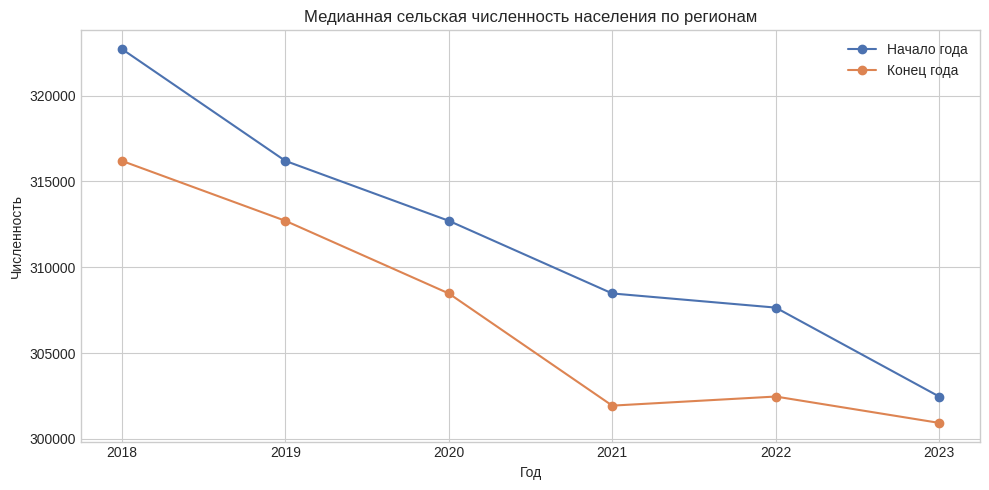

In [ ]:
# ==========================================
# ЯЧЕЙКА 20. ОБЩИЙ EDA ПО ГОДАМ
# ==========================================
# Смотрим общую годовую динамику по ключевым показателям.

year_summary = panel_main.groupby('year')[['rural_population_start', 'rural_population_end', 'rural_natural_increase', 'migration_net_total']].median().reset_index()
display(year_summary)

plt.figure(figsize=(10, 5))
plt.plot(year_summary['year'], year_summary['rural_population_start'], marker='o', label='Начало года')
plt.plot(year_summary['year'], year_summary['rural_population_end'], marker='o', label='Конец года')
plt.title('Медианная сельская численность населения по регионам')
plt.xlabel('Год')
plt.ylabel('Численность')
plt.legend()
save_current_fig('eda_population_median_by_year.png')


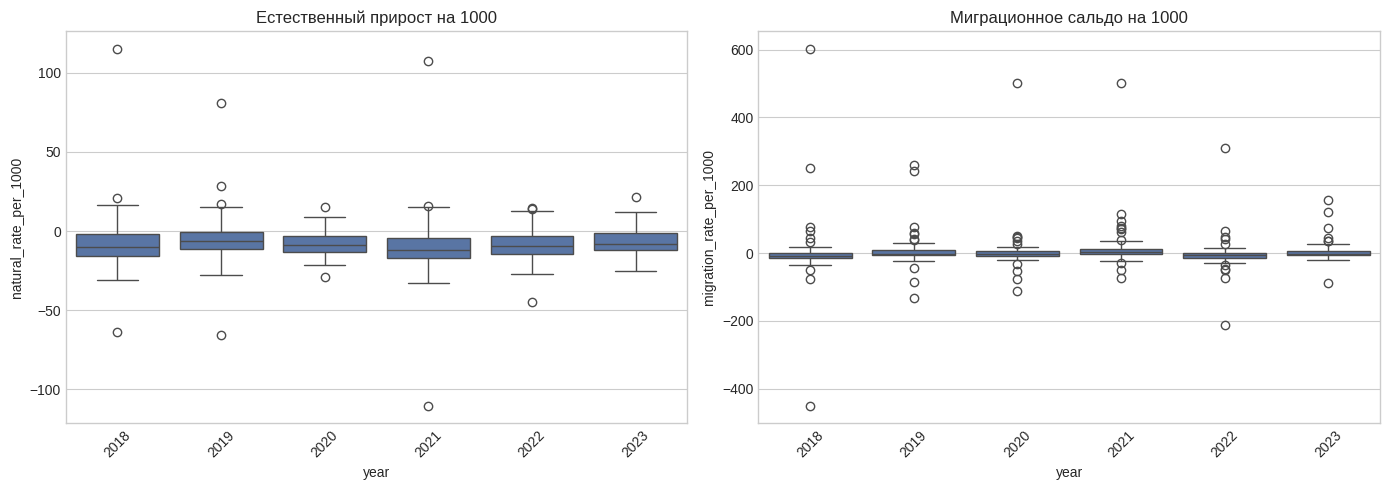

In [ ]:
# ==========================================
# ЯЧЕЙКА 21. BOXPLOT EDA ПО ЕСТЕСТВЕННОМУ И МИГРАЦИОННОМУ ДВИЖЕНИЮ
# ==========================================
# Полезно посмотреть распределения по годам и наличие выбросов.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=panel_main, x='year', y='natural_rate_per_1000', ax=axes[0])
axes[0].set_title('Естественный прирост на 1000')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=panel_main, x='year', y='migration_rate_per_1000', ax=axes[1])
axes[1].set_title('Миграционное сальдо на 1000')
axes[1].tick_params(axis='x', rotation=45)

save_current_fig('eda_boxplots_natural_migration.png')


Размер выборки H1: (174, 7)


,region,region,year,invest_per_rural_capita,invest_pc_win,log_invest_pc,migration_rate_per_1000
4,Алтайский край,Алтайский край,2022,6.412092e+05,6.412092e+05,13.371113,-8.644704
5,Алтайский край,Алтайский край,2023,6.229670e+05,6.229670e+05,13.342250,-1.925194
10,Амурская область,Амурская область,2022,3.251679e+06,3.251679e+06,14.994682,-12.605319
11,Амурская область,Амурская область,2023,3.888101e+05,3.888101e+05,12.870849,-10.140291
16,Архангельская область,Архангельская область,2022,1.497487e+06,1.497487e+06,14.219299,-12.424612


Квартильная таблица H1:


,quartile,count,mean,median,std
0,Q1_low,44,-5.602398,-4.983201,7.863341
1,Q2,43,-4.509467,-4.678848,9.485857
2,Q3,43,2.960186,-0.722677,14.867820
3,Q4_high,44,4.258608,-3.873534,66.590751


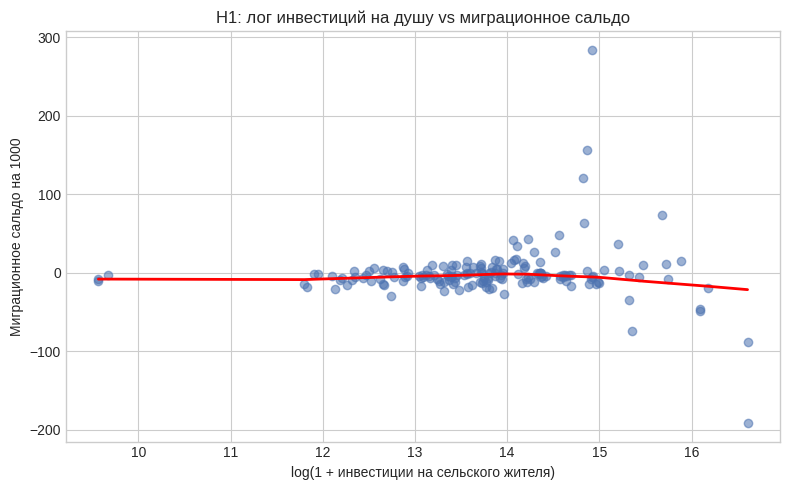

                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.017
Model:                                 OLS   Adj. R-squared:                  0.005
Method:                      Least Squares   F-statistic:                     1.712
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):              0.184
Time:                             14:23:51   Log-Likelihood:                -862.66
No. Observations:                      174   AIC:                             1731.
Df Residuals:                          171   BIC:                             1741.
Df Model:                                2                                         
Covariance Type:                       HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

,variable,coef,std_err,p_value,conf_low,conf_high
0,const,-21.083107,47.722345,0.658643,-114.617184,72.450970
1,log_invest_pc,1.149870,3.635848,0.751806,-5.976261,8.276000
2,year_2023,9.013848,5.057474,0.074703,-0.898618,18.926314


Интерпретация H1:
Устойчивой статистической связи не выявлено: coef = 1.1499, p-value = 0.7518, R² = 0.017.
H1-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 22. H1 — ИНВЕСТИЦИИ И МИГРАЦИОННОЕ САЛЬДО (ПЕРЕПИСАННАЯ ВЕРСИЯ)
# ==========================================
# ГИПОТЕЗА 1
# Логика гипотезы:
# проверяем, связан ли более высокий уровень инвестиций на сельского жителя
# с более благоприятным миграционным сальдо.
#
# Почему переписываем ячейку:
# в исходной версии инвестиции использовались в исходном масштабе,
# из-за чего возникал очень большой condition number и модель хуже интерпретировалась.
# Здесь мы:
# 1) очищаем данные от выбросов и невозможных значений,
# 2) строим логарифм инвестиций,
# 3) оцениваем модель в более устойчивой форме,
# 4) выводим компактную интерпретацию результата.

h1_df = model_df[['region', 'year', 'invest_per_rural_capita', 'migration_rate_per_1000']].copy()

# Удаляем бесконечности, если они где-то остались после прошлых шагов.
h1_df = h1_df.replace([np.inf, -np.inf], np.nan)

# Оставляем только наблюдения, где есть обе ключевые переменные.
h1_df = h1_df.dropna(subset=['invest_per_rural_capita', 'migration_rate_per_1000']).copy()

# Убираем невалидные инвестиции: логарифм можно брать только от положительных значений.
h1_df = h1_df[h1_df['invest_per_rural_capita'] > 0].copy()

# Мягкая винзоризация хвостов для стабилизации оценок.
q_low, q_high = h1_df['invest_per_rural_capita'].quantile([0.01, 0.99])
h1_df['invest_pc_win'] = h1_df['invest_per_rural_capita'].clip(q_low, q_high)

# Логарифмированная версия инвестиционного показателя.
h1_df['log_invest_pc'] = np.log1p(h1_df['invest_pc_win'])

print('Размер выборки H1:', h1_df.shape)
display(h1_df[['region', 'year', 'invest_per_rural_capita', 'invest_pc_win', 'log_invest_pc', 'migration_rate_per_1000']].head())

# Квартильная таблица для описательного анализа.
h1_table = quartile_table(h1_df, 'log_invest_pc', 'migration_rate_per_1000')
print('Квартильная таблица H1:')
display(h1_table)

# График в лог-шкале по оси X.
plt.figure(figsize=(8, 5))
plt.scatter(h1_df['log_invest_pc'], h1_df['migration_rate_per_1000'], alpha=0.55)
add_lowess(plt.gca(), h1_df['log_invest_pc'], h1_df['migration_rate_per_1000'])
plt.title('H1: лог инвестиций на душу vs миграционное сальдо')
plt.xlabel('log(1 + инвестиции на сельского жителя)')
plt.ylabel('Миграционное сальдо на 1000')
save_current_fig('H1_log_invest_vs_migration.png')

# Основная регрессия с фиксацией по году.
h1_model = run_ols(h1_df, 'migration_rate_per_1000', ['log_invest_pc'])
print(h1_model.summary() if h1_model else 'Недостаточно данных для H1')

# Компактная таблица коэффициентов для дальнейшего текста главы.
if h1_model is not None:
    h1_coef_table = pd.DataFrame({
        'variable': h1_model.params.index,
        'coef': h1_model.params.values,
        'std_err': h1_model.bse.values,
        'p_value': h1_model.pvalues.values,
        'conf_low': h1_model.conf_int()[0].values,
        'conf_high': h1_model.conf_int()[1].values,
    })
    print('Таблица коэффициентов H1:')
    display(h1_coef_table)

    invest_coef = h1_model.params.get('log_invest_pc', np.nan)
    invest_p = h1_model.pvalues.get('log_invest_pc', np.nan)
    invest_r2 = h1_model.rsquared

    print('Интерпретация H1:')
    if pd.notna(invest_p):
        if invest_p < 0.05:
            print(f'Обнаружена статистически значимая связь: coef = {invest_coef:.4f}, p-value = {invest_p:.4f}, R² = {invest_r2:.3f}.')
        elif invest_p < 0.10:
            print(f'Наблюдается погранично значимая тенденция: coef = {invest_coef:.4f}, p-value = {invest_p:.4f}, R² = {invest_r2:.3f}.')
        else:
            print(f'Устойчивой статистической связи не выявлено: coef = {invest_coef:.4f}, p-value = {invest_p:.4f}, R² = {invest_r2:.3f}.')

# Сохраняем таблицы H1 на диск, чтобы потом удобно использовать в тексте работы.
h1_df.to_csv(TABLES_DIR / 'H1_working_dataset.csv', index=False)
if not h1_table.empty:
    h1_table.to_csv(TABLES_DIR / 'H1_quartile_table.csv', index=False)
if h1_model is not None:
    h1_coef_table.to_csv(TABLES_DIR / 'H1_regression_coefficients.csv', index=False)

print('H1-артефакты сохранены')

Размер выборки H2: (174, 6)


,region,region,year,housing_input_m2_per_person_proxy,housing_win,pop_change_rate_per_1000
4,Алтайский край,Алтайский край,2022,240.546105,240.546105,-13.057058
5,Алтайский край,Алтайский край,2023,410.377120,410.377120,-11.301229
10,Амурская область,Амурская область,2022,601.891621,601.891621,-16.155707
11,Амурская область,Амурская область,2023,134.308556,134.308556,-12.619959
16,Архангельская область,Архангельская область,2022,566.793751,566.793751,-20.691673


Квартильная таблица H2:


,quartile,count,mean,median,std
0,Q1_low,44,-8.545752,-9.540825,7.509973
1,Q2,43,-9.779519,-10.626708,8.536589
2,Q3,43,-9.036127,-8.460530,9.168893
3,Q4_high,44,-4.008144,-5.355013,9.280279


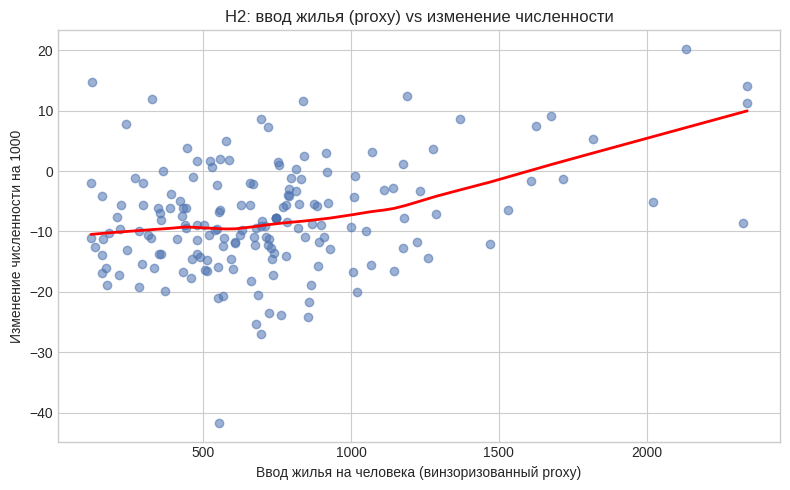

                               OLS Regression Results                               
Dep. Variable:     pop_change_rate_per_1000   R-squared:                       0.122
Model:                                  OLS   Adj. R-squared:                  0.112
Method:                       Least Squares   F-statistic:                     7.533
Date:                      Thu, 09 Apr 2026   Prob (F-statistic):           0.000732
Time:                              14:23:53   Log-Likelihood:                -614.81
No. Observations:                       174   AIC:                             1236.
Df Residuals:                           171   BIC:                             1245.
Df Model:                                 2                                         
Covariance Type:                        HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

,variable,coef,std_err,p_value,conf_low,conf_high
0,const,-13.880249,1.696896,2.843397e-16,-17.206103,-10.554395
1,housing_win,0.006836,0.001829,1.860549e-04,0.003251,0.010421
2,year_2023,2.211351,1.290272,8.655384e-02,-0.317537,4.740238


Интерпретация H2:
Ввод жилья статистически значимо связан с динамикой численности: coef = 0.0068, p-value = 0.0002, R² = 0.122.
H2-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 23. H2 — ЖИЛИЩНОЕ СТРОИТЕЛЬСТВО И ИЗМЕНЕНИЕ ЧИСЛЕННОСТИ (НОВАЯ ВЕРСИЯ)
# ==========================================
# ГППОТЕЗА 2:
# более высокий ввод жилья на сельского жителя ассоциирован
# с менее негативной (или более позитивной) динамикой численности населения.

h2_df = model_df[['region', 'year',
                  'housing_input_m2_per_person_proxy',
                  'pop_change_rate_per_1000']].copy()

# Защита от бесконечностей
h2_df = h2_df.replace([np.inf, -np.inf], np.nan)

# Оставляем только наблюдения с обоими показателями
h2_df = h2_df.dropna(subset=['housing_input_m2_per_person_proxy',
                             'pop_change_rate_per_1000']).copy()

# Мягкая винзоризация хвостов по вводу жилья
q_low, q_high = h2_df['housing_input_m2_per_person_proxy'].quantile([0.01, 0.99])
h2_df['housing_win'] = h2_df['housing_input_m2_per_person_proxy'].clip(q_low, q_high)

print('Размер выборки H2:', h2_df.shape)
display(h2_df[['region', 'year',
               'housing_input_m2_per_person_proxy',
               'housing_win',
               'pop_change_rate_per_1000']].head())

# Квартильная таблица по вводу жилья
h2_table = quartile_table(h2_df, 'housing_win', 'pop_change_rate_per_1000')
print('Квартильная таблица H2:')
display(h2_table)

# Диаграмма рассеяния + LOWESS
plt.figure(figsize=(8, 5))
plt.scatter(h2_df['housing_win'], h2_df['pop_change_rate_per_1000'], alpha=0.55)
add_lowess(plt.gca(), h2_df['housing_win'], h2_df['pop_change_rate_per_1000'])
plt.title('H2: ввод жилья (proxy) vs изменение численности')
plt.xlabel('Ввод жилья на человека (винзоризованный proxy)')
plt.ylabel('Изменение численности на 1000')
save_current_fig('H2_housing_vs_population_change_win.png')

# Основная регрессия (с фиксацией по году)
h2_model = run_ols(h2_df, 'pop_change_rate_per_1000', ['housing_win'])
print(h2_model.summary() if h2_model else 'Недостаточно данных для H2')

# Таблица коэффициентов
if h2_model is not None:
    h2_coef_table = pd.DataFrame({
        'variable': h2_model.params.index,
        'coef': h2_model.params.values,
        'std_err': h2_model.bse.values,
        'p_value': h2_model.pvalues.values,
        'conf_low': h2_model.conf_int()[0].values,
        'conf_high': h2_model.conf_int()[1].values,
    })
    print('Таблица коэффициентов H2:')
    display(h2_coef_table)

    coef_housing = h2_model.params.get('housing_win', np.nan)
    p_housing = h2_model.pvalues.get('housing_win', np.nan)
    r2_h2 = h2_model.rsquared

    print('Интерпретация H2:')
    if pd.notna(p_housing):
        if p_housing < 0.05:
            print(f'Ввод жилья статистически значимо связан с динамикой численности: '
                  f'coef = {coef_housing:.4f}, p-value = {p_housing:.4f}, R² = {r2_h2:.3f}.')
        elif p_housing < 0.10:
            print(f'Есть погранично значимая тенденция: '
                  f'coef = {coef_housing:.4f}, p-value = {p_housing:.4f}, R² = {r2_h2:.3f}.')
        else:
            print(f'Устойчивой статистической связи не выявлено: '
                  f'coef = {coef_housing:.4f}, p-value = {p_housing:.4f}, R² = {r2_h2:.3f}.')

# Сохранение артефактов H2
h2_df.to_csv(TABLES_DIR / 'H2_working_dataset.csv', index=False)
if not h2_table.empty:
    h2_table.to_csv(TABLES_DIR / 'H2_quartile_table.csv', index=False)
if h2_model is not None:
    h2_coef_table.to_csv(TABLES_DIR / 'H2_regression_coefficients.csv', index=False)

print('H2-артефакты сохранены')

Размер выборки H3: (174, 6)


,region,region,year,service_access_index,service_win,migration_rate_per_1000
4,Алтайский край,Алтайский край,2022,0.867576,0.867576,-8.644704
5,Алтайский край,Алтайский край,2023,0.107199,0.107199,-1.925194
10,Амурская область,Амурская область,2022,-0.389273,-0.389273,-12.605319
11,Амурская область,Амурская область,2023,-0.884539,-0.884539,-10.140291
16,Архангельская область,Архангельская область,2022,0.619465,0.619465,-12.424612


Квартильная таблица H3:


,quartile,count,mean,median,std
0,Q1_low,44,1.630276,-4.647086,66.156550
1,Q2,43,-6.447055,-6.490232,11.225055
2,Q3,43,-1.334707,-0.722677,8.865914
3,Q4_high,44,3.116767,-1.417285,15.722275


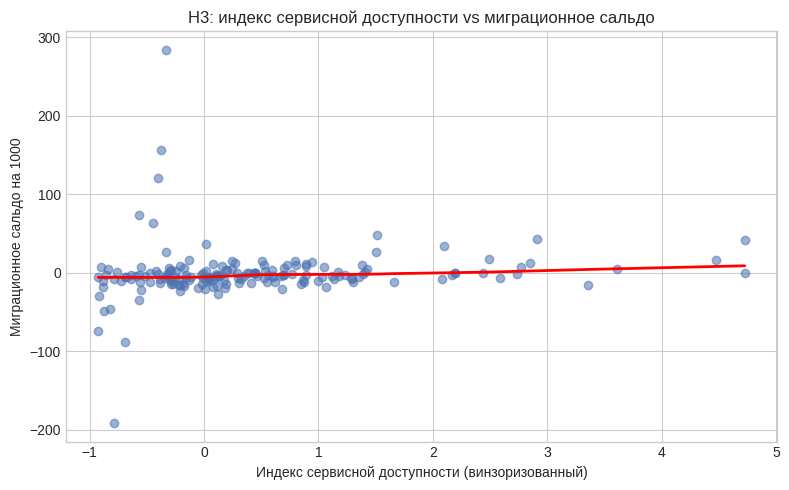

                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.029
Model:                                 OLS   Adj. R-squared:                  0.018
Method:                      Least Squares   F-statistic:                     2.025
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):              0.135
Time:                             14:23:54   Log-Likelihood:                -861.57
No. Observations:                      174   AIC:                             1729.
Df Residuals:                          171   BIC:                             1739.
Df Model:                                2                                         
Covariance Type:                       HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------


,variable,coef,std_err,p_value,conf_low,conf_high
0,const,-6.487051,5.018953,0.196180,-16.324018,3.349915
1,service_win,3.772664,2.274620,0.097198,-0.685509,8.230838
2,year_2023,8.381322,5.230817,0.109090,-1.870891,18.633534


Интерпретация H3:
Наблюдается погранично значимая положительная тенденция: coef = 3.7727, p-value = 0.0972, R² = 0.029.
H3-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 24. H3 — ДОСТУПНОСТЬ УСЛУГ И МИГРАЦИЯ (НОВАЯ ВЕРСИЯ)
# ==========================================
# ГИПОТЕЗА 3:
# более высокая доступность сервисов (service_access_index)
# ассоциирована с менее негативным / более благоприятным миграционным сальдо.

h3_df = model_df[['region', 'year',
                  'service_access_index',
                  'migration_rate_per_1000']].copy()

# Защита от бесконечностей
h3_df = h3_df.replace([np.inf, -np.inf], np.nan)

# Оставляем только наблюдения с обеими переменными
h3_df = h3_df.dropna(subset=['service_access_index',
                             'migration_rate_per_1000']).copy()

# Мягкая винзоризация индекса доступности услуг
q_low, q_high = h3_df['service_access_index'].quantile([0.01, 0.99])
h3_df['service_win'] = h3_df['service_access_index'].clip(q_low, q_high)

print('Размер выборки H3:', h3_df.shape)
display(h3_df[['region', 'year',
               'service_access_index',
               'service_win',
               'migration_rate_per_1000']].head())

# Квартильная таблица по индексу доступности услуг
h3_table = quartile_table(h3_df, 'service_win', 'migration_rate_per_1000')
print('Квартильная таблица H3:')
display(h3_table)

# Диаграмма рассеяния + LOWESS
plt.figure(figsize=(8, 5))
plt.scatter(h3_df['service_win'], h3_df['migration_rate_per_1000'], alpha=0.55)
add_lowess(plt.gca(), h3_df['service_win'], h3_df['migration_rate_per_1000'])
plt.title('H3: индекс сервисной доступности vs миграционное сальдо')
plt.xlabel('Индекс сервисной доступности (винзоризованный)')
plt.ylabel('Миграционное сальдо на 1000')
save_current_fig('H3_service_vs_migration_win.png')

# Основная регрессия (с фиксацией по году)
h3_model = run_ols(h3_df, 'migration_rate_per_1000', ['service_win'])
print(h3_model.summary() if h3_model else 'Недостаточно данных для H3')

# Таблица коэффициентов
if h3_model is not None:
    h3_coef_table = pd.DataFrame({
        'variable': h3_model.params.index,
        'coef': h3_model.params.values,
        'std_err': h3_model.bse.values,
        'p_value': h3_model.pvalues.values,
        'conf_low': h3_model.conf_int()[0].values,
        'conf_high': h3_model.conf_int()[1].values,
    })
    print('Таблица коэффициентов H3:')
    display(h3_coef_table)

    coef_serv = h3_model.params.get('service_win', np.nan)
    p_serv = h3_model.pvalues.get('service_win', np.nan)
    r2_h3 = h3_model.rsquared

    print('Интерпретация H3:')
    if pd.notna(p_serv):
        if p_serv < 0.05:
            print(f'Индекс доступности услуг статистически значимо связан с миграционным сальдо: '
                  f'coef = {coef_serv:.4f}, p-value = {p_serv:.4f}, R² = {r2_h3:.3f}.')
        elif p_serv < 0.10:
            print(f'Наблюдается погранично значимая положительная тенденция: '
                  f'coef = {coef_serv:.4f}, p-value = {p_serv:.4f}, R² = {r2_h3:.3f}.')
        else:
            print(f'Устойчивой статистической связи не выявлено: '
                  f'coef = {coef_serv:.4f}, p-value = {p_serv:.4f}, R² = {r2_h3:.3f}.')

# Сохранение артефактов H3
h3_df.to_csv(TABLES_DIR / 'H3_working_dataset.csv', index=False)
if not h3_table.empty:
    h3_table.to_csv(TABLES_DIR / 'H3_quartile_table.csv', index=False)
if h3_model is not None:
    h3_coef_table.to_csv(TABLES_DIR / 'H3_regression_coefficients.csv', index=False)

print('H3-артефакты сохранены')

Размер выборки H4: (174, 9)


,region,region,year,transport_housing_index_win,economic_activity_index_win,roads_x_econ_win,migration_rate_per_1000
4,Алтайский край,Алтайский край,2022,1.922655,1.312646,2.523766,-8.644704
5,Алтайский край,Алтайский край,2023,3.964917,1.058217,4.195743,-1.925194
10,Амурская область,Амурская область,2022,-0.366718,1.600593,-0.586967,-12.605319
11,Амурская область,Амурская область,2023,-0.417889,1.297697,-0.542293,-10.140291
16,Архангельская область,Архангельская область,2022,-0.178346,-0.104065,0.018560,-12.424612


Квартильная таблица H4 (interaction):


,quartile,count,mean,median,std
0,Q1_low,44,8.627177,-3.797263,55.290449
1,Q2,43,-5.509398,-5.636742,9.948515
2,Q3,43,-5.673535,-2.398164,32.183257
3,Q4_high,44,-0.556262,-0.375457,23.986142


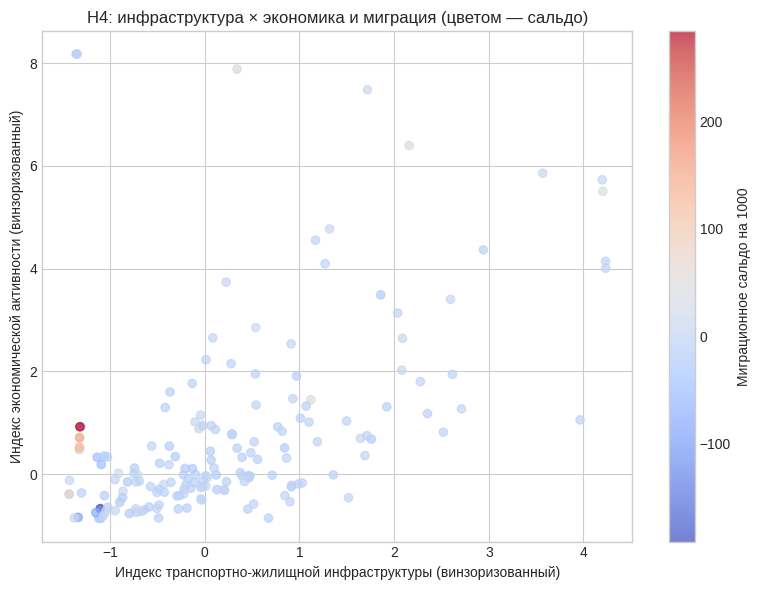

                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.049
Model:                                 OLS   Adj. R-squared:                  0.027
Method:                      Least Squares   F-statistic:                     5.790
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):           0.000216
Time:                             14:23:56   Log-Likelihood:                -859.74
No. Observations:                      174   AIC:                             1729.
Df Residuals:                          169   BIC:                             1745.
Df Model:                                4                                         
Covariance Type:                       HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

,variable,coef,std_err,p_value,conf_low,conf_high
0,const,-7.829872,4.498685,0.081775,-16.647133,0.987389
1,transport_win,-4.543103,4.253005,0.285426,-12.878839,3.792633
2,econ_win,3.277801,2.240130,0.143407,-1.112774,7.668376
3,roads_x_econ_win,0.970319,1.007563,0.335530,-1.004468,2.945105
4,year_2023,8.909795,5.386213,0.098090,-1.646988,19.466578


Интерпретация H4:
Статистически значимого совместного эффекта не выявлено: p-value = 0.3355, R² = 0.049.
H4-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 25. H4 — СОВМЕСТНЫЙ ЭФФЕКТ ИНФРАСТРУКТУРЫ И ЭКОНОМИКИ (НОВАЯ ВЕРСИЯ)
# ==========================================
# ГИПОТЕЗА 4:
# эффект транспортно-жилищной инфраструктуры на миграцию усиливается
# в регионах с более высокой экономической активностью (interaction-термин).

h4_df = model_df[['region', 'year',
                  'transport_housing_index',
                  'economic_activity_index',
                  'migration_rate_per_1000']].copy()

# Защита от бесконечностей
h4_df = h4_df.replace([np.inf, -np.inf], np.nan)

# Выбрасываем наблюдения без нужных переменных
h4_df = h4_df.dropna(subset=['transport_housing_index',
                             'economic_activity_index',
                             'migration_rate_per_1000']).copy()

# Небольшая винзоризация по обоим индексам
for col in ['transport_housing_index', 'economic_activity_index']:
    q_low, q_high = h4_df[col].quantile([0.01, 0.99])
    h4_df[col + '_win'] = h4_df[col].clip(q_low, q_high)

# Interaction-термин на винзоризованных величинах
h4_df['roads_x_econ_win'] = h4_df['transport_housing_index_win'] * h4_df['economic_activity_index_win']

print('Размер выборки H4:', h4_df.shape)
display(h4_df[['region', 'year',
               'transport_housing_index_win',
               'economic_activity_index_win',
               'roads_x_econ_win',
               'migration_rate_per_1000']].head())

# Диагностика описательно: квартильный разрез по interaction-термину
h4_table = quartile_table(h4_df, 'roads_x_econ_win', 'migration_rate_per_1000')
print('Квартильная таблица H4 (interaction):')
display(h4_table)

# Для наглядности: scatter по двум индексам и цвет по миграции
plt.figure(figsize=(8, 6))
sc = plt.scatter(h4_df['transport_housing_index_win'],
                 h4_df['economic_activity_index_win'],
                 c=h4_df['migration_rate_per_1000'],
                 cmap='coolwarm', alpha=0.7)
plt.colorbar(sc, label='Миграционное сальдо на 1000')
plt.xlabel('Индекс транспортно-жилищной инфраструктуры (винзоризованный)')
plt.ylabel('Индекс экономической активности (винзоризованный)')
plt.title('H4: инфраструктура × экономика и миграция (цветом — сальдо)')
save_current_fig('H4_infra_econ_interaction_scatter.png')

# Регрессия с interaction-термином и фиксированием по году
h4_model = run_ols(
    h4_df.rename(columns={
        'transport_housing_index_win': 'transport_win',
        'economic_activity_index_win': 'econ_win',
        'roads_x_econ_win': 'roads_x_econ_win'
    }),
    'migration_rate_per_1000',
    ['transport_win', 'econ_win', 'roads_x_econ_win']
)

print(h4_model.summary() if h4_model else 'Недостаточно данных для H4')

# Таблица коэффициентов
if h4_model is not None:
    h4_coef_table = pd.DataFrame({
        'variable': h4_model.params.index,
        'coef': h4_model.params.values,
        'std_err': h4_model.bse.values,
        'p_value': h4_model.pvalues.values,
        'conf_low': h4_model.conf_int()[0].values,
        'conf_high': h4_model.conf_int()[1].values,
    })
    print('Таблица коэффициентов H4:')
    display(h4_coef_table)

    p_int = h4_model.pvalues.get('roads_x_econ_win', np.nan)
    r2_h4 = h4_model.rsquared

    print('Интерпретация H4:')
    if pd.notna(p_int):
        if p_int < 0.05:
            print(f'Interaction инфраструктура×экономика статистически значим: '
                  f'p-value = {p_int:.4f}, R² = {r2_h4:.3f}.')
        elif p_int < 0.10:
            print(f'Есть пограничная тенденция interaction-эффекта: '
                  f'p-value = {p_int:.4f}, R² = {r2_h4:.3f}.')
        else:
            print(f'Статистически значимого совместного эффекта не выявлено: '
                  f'p-value = {p_int:.4f}, R² = {r2_h4:.3f}.')

# Сохранение артефактов H4
h4_df.to_csv(TABLES_DIR / 'H4_working_dataset.csv', index=False)
if not h4_table.empty:
    h4_table.to_csv(TABLES_DIR / 'H4_quartile_table.csv', index=False)
if h4_model is not None:
    h4_coef_table.to_csv(TABLES_DIR / 'H4_regression_coefficients.csv', index=False)

print('H4-артефакты сохранены')

Размер выборки H5: (174, 6)


,region,region,year,social_infra_index,social_win,migration_rate_per_1000
4,Алтайский край,Алтайский край,2022,1.650692,1.650692,-8.644704
5,Алтайский край,Алтайский край,2023,4.299938,4.299938,-1.925194
10,Амурская область,Амурская область,2022,-0.539741,-0.539741,-12.605319
11,Амурская область,Амурская область,2023,-0.387838,-0.387838,-10.140291
16,Архангельская область,Архангельская область,2022,0.334643,0.334643,-12.424612


Квартильная таблица H5:


,quartile,count,mean,median,std
0,Q1_low,46,0.931407,-5.447763,65.030969
1,Q2,41,-5.040552,-5.021149,9.265292
2,Q3,43,-2.970501,-4.183846,12.619708
3,Q4_high,44,3.768263,-0.375457,13.041842


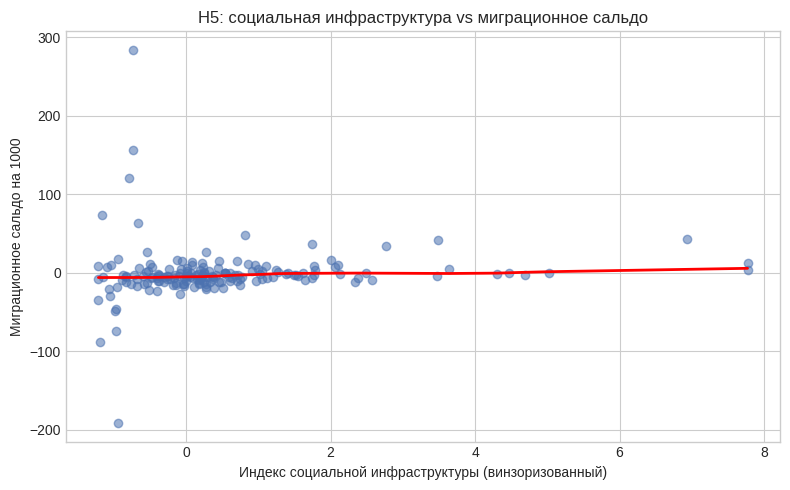

                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.020
Model:                                 OLS   Adj. R-squared:                  0.009
Method:                      Least Squares   F-statistic:                     1.527
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):              0.220
Time:                             14:23:57   Log-Likelihood:                -862.35
No. Observations:                      174   AIC:                             1731.
Df Residuals:                          171   BIC:                             1740.
Df Model:                                2                                         
Covariance Type:                       HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
co

,variable,coef,std_err,p_value,conf_low,conf_high
0,const,-5.443890,4.684210,0.245163,-14.624773,3.736993
1,social_win,1.646134,1.666373,0.323224,-1.619896,4.912164
2,year_2023,7.807972,5.180431,0.131758,-2.345487,17.961430


Интерпретация H5:
Устойчивой статистической связи не выявлено: coef = 1.6461, p-value = 0.3232, R² = 0.020.
H5-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 26. H5 — СОЦИАЛЬНАЯ ИНФРАСТРУКТУРА И МИГРАЦИЯ (НОВАЯ ВЕРСИЯ)
# ==========================================
# ГИПОТЕЗА 5:
# более развитая социальная инфраструктура (social_infra_index)
# ассоциирована с менее негативным / более благоприятным миграционным сальдо.

h5_df = model_df[['region', 'year',
                  'social_infra_index',
                  'migration_rate_per_1000']].copy()

# Защита от бесконечностей
h5_df = h5_df.replace([np.inf, -np.inf], np.nan)

# Оставляем только наблюдения с обеими переменными
h5_df = h5_df.dropna(subset=['social_infra_index',
                             'migration_rate_per_1000']).copy()

# Мягкая винзоризация индекса социальной инфраструктуры
q_low, q_high = h5_df['social_infra_index'].quantile([0.01, 0.99])
h5_df['social_win'] = h5_df['social_infra_index'].clip(q_low, q_high)

print('Размер выборки H5:', h5_df.shape)
display(h5_df[['region', 'year',
               'social_infra_index',
               'social_win',
               'migration_rate_per_1000']].head())

# Квартильная таблица по индексу социальной инфраструктуры
h5_table = quartile_table(h5_df, 'social_win', 'migration_rate_per_1000')
print('Квартильная таблица H5:')
display(h5_table)

# Диаграмма рассеяния + LOWESS
plt.figure(figsize=(8, 5))
plt.scatter(h5_df['social_win'], h5_df['migration_rate_per_1000'], alpha=0.55)
add_lowess(plt.gca(), h5_df['social_win'], h5_df['migration_rate_per_1000'])
plt.title('H5: социальная инфраструктура vs миграционное сальдо')
plt.xlabel('Индекс социальной инфраструктуры (винзоризованный)')
plt.ylabel('Миграционное сальдо на 1000')
save_current_fig('H5_social_vs_migration_win.png')

# Основная регрессия (с фиксацией по году)
h5_model = run_ols(h5_df, 'migration_rate_per_1000', ['social_win'])
print(h5_model.summary() if h5_model else 'Недостаточно данных для H5')

# Таблица коэффициентов
if h5_model is not None:
    h5_coef_table = pd.DataFrame({
        'variable': h5_model.params.index,
        'coef': h5_model.params.values,
        'std_err': h5_model.bse.values,
        'p_value': h5_model.pvalues.values,
        'conf_low': h5_model.conf_int()[0].values,
        'conf_high': h5_model.conf_int()[1].values,
    })
    print('Таблица коэффициентов H5:')
    display(h5_coef_table)

    coef_social = h5_model.params.get('social_win', np.nan)
    p_social = h5_model.pvalues.get('social_win', np.nan)
    r2_h5 = h5_model.rsquared

    print('Интерпретация H5:')
    if pd.notna(p_social):
        if p_social < 0.05:
            print(f'Индекс социальной инфраструктуры статистически значимо связан '
                  f'с миграционным сальдо: coef = {coef_social:.4f}, '
                  f'p-value = {p_social:.4f}, R² = {r2_h5:.3f}.')
        elif p_social < 0.10:
            print(f'Наблюдается погранично значимая положительная тенденция: '
                  f'coef = {coef_social:.4f}, p-value = {p_social:.4f}, '
                  f'R² = {r2_h5:.3f}.')
        else:
            print(f'Устойчивой статистической связи не выявлено: '
                  f'coef = {coef_social:.4f}, p-value = {p_social:.4f}, '
                  f'R² = {r2_h5:.3f}.')

# Сохранение артефактов H5
h5_df.to_csv(TABLES_DIR / 'H5_working_dataset.csv', index=False)
if not h5_table.empty:
    h5_table.to_csv(TABLES_DIR / 'H5_quartile_table.csv', index=False)
if h5_model is not None:
    h5_coef_table.to_csv(TABLES_DIR / 'H5_regression_coefficients.csv', index=False)

print('H5-артефакты сохранены')


Размер выборки H6: (174, 9)


,region,region,year,economic_activity_index_win,transport_housing_index_win,econ_x_transport_win,migration_rate_per_1000
4,Алтайский край,Алтайский край,2022,1.312646,1.922655,2.523766,-8.644704
5,Алтайский край,Алтайский край,2023,1.058217,3.964917,4.195743,-1.925194
10,Амурская область,Амурская область,2022,1.600593,-0.366718,-0.586967,-12.605319
11,Амурская область,Амурская область,2023,1.297697,-0.417889,-0.542293,-10.140291
16,Архангельская область,Архангельская область,2022,-0.104065,-0.178346,0.018560,-12.424612


Квартильная таблица H6 (economy × infrastructure):


,quartile,count,mean,median,std
0,Q1_low,44,8.627177,-3.797263,55.290449
1,Q2,43,-5.509398,-5.636742,9.948515
2,Q3,43,-5.673535,-2.398164,32.183257
3,Q4_high,44,-0.556262,-0.375457,23.986142


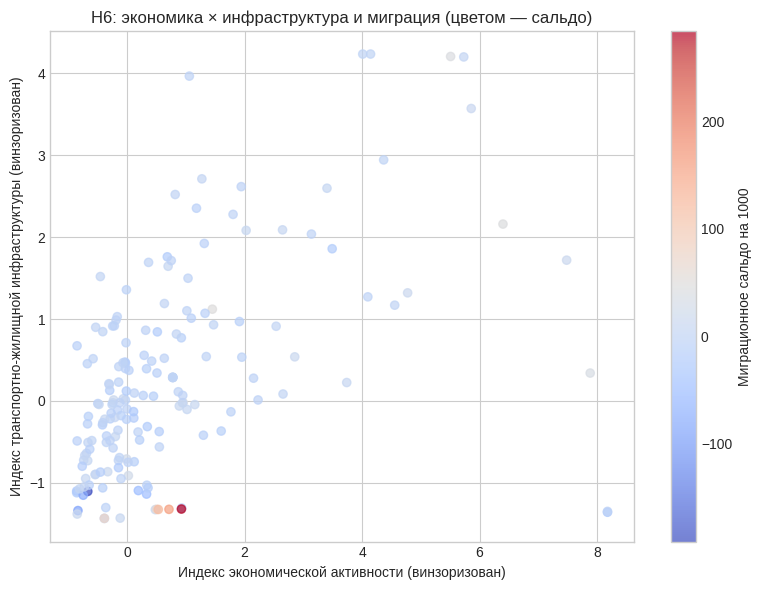

                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.049
Model:                                 OLS   Adj. R-squared:                  0.027
Method:                      Least Squares   F-statistic:                     5.790
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):           0.000216
Time:                             14:23:59   Log-Likelihood:                -859.74
No. Observations:                      174   AIC:                             1729.
Df Residuals:                          169   BIC:                             1745.
Df Model:                                4                                         
Covariance Type:                       HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

,variable,coef,std_err,p_value,conf_low,conf_high
0,const,-7.829872,4.498685,0.081775,-16.647133,0.987389
1,econ_win,3.277801,2.240130,0.143407,-1.112774,7.668376
2,transport_win,-4.543103,4.253005,0.285426,-12.878839,3.792633
3,econ_x_transport_win,0.970319,1.007563,0.335530,-1.004468,2.945105
4,year_2023,8.909795,5.386213,0.098090,-1.646988,19.466578


Интерпретация H6:
Статистически значимого взаимодействия экономики и инфраструктуры на миграцию не выявлено: interaction p-value = 0.3355, R² = 0.049.
H6-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 27. H6 — ЭКОНОМИКА × ИНФРАСТРУКТУРА И МИГРАЦИЯ (ВАРИАНТ БЕЗ РЕСУРСНОГО СЧЁТЧИКА)ВАРИАНТ Гипотезы 4
# ==========================================
# Техническая формулировка: версия гипотезы 4 с доработками на перспективу
# проверяем, усиливается ли связь инфраструктурного индекса
# с миграционным сальдо в муниципалитетах с более высокой экономической активностью.
# Техническая ячейка - представляет собой исследование в другой формулиовке гипотезы 4 из ячейки 25.
# В итоговую публикацию не идет, остается вариантом для дальнейшей доработки блока гипотез на большем объеме даных.
h6_df = model_df[['region', 'year',
                  'economic_activity_index',
                  'transport_housing_index',
                  'migration_rate_per_1000']].copy()

# Защита от бесконечностей и пропусков
h6_df = h6_df.replace([np.inf, -np.inf], np.nan)
h6_df = h6_df.dropna(subset=['economic_activity_index',
                             'transport_housing_index',
                             'migration_rate_per_1000']).copy()

# Винзоризация двух индексов
for col in ['economic_activity_index', 'transport_housing_index']:
    q_low, q_high = h6_df[col].quantile([0.01, 0.99])
    h6_df[col + '_win'] = h6_df[col].clip(q_low, q_high)

# Interaction-термин экономика × инфраструктура
h6_df['econ_x_transport_win'] = (
    h6_df['economic_activity_index_win'] *
    h6_df['transport_housing_index_win']
)

print('Размер выборки H6:', h6_df.shape)
display(h6_df[['region', 'year',
               'economic_activity_index_win',
               'transport_housing_index_win',
               'econ_x_transport_win',
               'migration_rate_per_1000']].head())

# Квартильный разрез по interaction-термину
h6_table = quartile_table(h6_df, 'econ_x_transport_win', 'migration_rate_per_1000')
print('Квартильная таблица H6 (economy × infrastructure):')
display(h6_table)

# Визуализация
plt.figure(figsize=(8, 6))
sc = plt.scatter(h6_df['economic_activity_index_win'],
                 h6_df['transport_housing_index_win'],
                 c=h6_df['migration_rate_per_1000'],
                 cmap='coolwarm', alpha=0.7)
plt.colorbar(sc, label='Миграционное сальдо на 1000')
plt.xlabel('Индекс экономической активности (винзоризован)')
plt.ylabel('Индекс транспортно-жилищной инфраструктуры (винзоризован)')
plt.title('H6: экономика × инфраструктура и миграция (цветом — сальдо)')
save_current_fig('H6_econ_transport_interaction_scatter.png')

# Регрессия с interaction-термином
h6_reg_df = h6_df.rename(columns={
    'economic_activity_index_win': 'econ_win',
    'transport_housing_index_win': 'transport_win',
})
h6_model = run_ols(
    h6_reg_df,
    'migration_rate_per_1000',
    ['econ_win', 'transport_win', 'econ_x_transport_win']
)

print(h6_model.summary() if h6_model else 'Недостаточно данных для H6')

# Таблица коэффициентов и интерпретация
if h6_model is not None:
    h6_coef_table = pd.DataFrame({
        'variable': h6_model.params.index,
        'coef': h6_model.params.values,
        'std_err': h6_model.bse.values,
        'p_value': h6_model.pvalues.values,
        'conf_low': h6_model.conf_int()[0].values,
        'conf_high': h6_model.conf_int()[1].values,
    })
    print('Таблица коэффициентов H6:')
    display(h6_coef_table)

    p_int = h6_model.pvalues.get('econ_x_transport_win', np.nan)
    r2_h6 = h6_model.rsquared

    print('Интерпретация H6:')
    if pd.notna(p_int):
        if p_int < 0.05:
            print(f'Статистически значимый совместный эффект экономики и инфраструктуры: '
                  f'interaction p-value = {p_int:.4f}, R² = {r2_h6:.3f}.')
        elif p_int < 0.10:
            print(f'Наблюдается пограничная тенденция совместного эффекта экономики и инфраструктуры: '
                  f'interaction p-value = {p_int:.4f}, R² = {r2_h6:.3f}.')
        else:
            print(f'Статистически значимого взаимодействия экономики и инфраструктуры '
                  f'на миграцию не выявлено: interaction p-value = {p_int:.4f}, '
                  f'R² = {r2_h6:.3f}.')

# Сохранение артефактов H6
h6_df.to_csv(TABLES_DIR / 'H6_working_dataset.csv', index=False)
if not h6_table.empty:
    h6_table.to_csv(TABLES_DIR / 'H6_quartile_table.csv', index=False)
if h6_model is not None:
    h6_coef_table.to_csv(TABLES_DIR / 'H6_regression_coefficients.csv', index=False)

print('H6-артефакты сохранены')

# Выводы - предположиельные - ячейка используется как вариант развития гипотезы 4 при дляльнейших исследованиях
# В H6 взаимодействие экономики и инфраструктуры на миграцию
# не подтверждается: коэффициент interaction-термина статистически
# незначим (p ≈ 0.34), а модель объясняет лишь около 5 % вариации
# миграционного сальдо между муниципалитетами.

# Полученный результат скорее говорит о том, что даже сочетание
# более развитой экономики и инфраструктуры не даёт устойчивого
# «миграционного бонуса» поверх общих макрошоков (например, сдвига 2023 г.),
# а индивидуальные траектории территорий определяются иными факторами.

,region,region,year,cluster_dbscan,cluster_kmeans,PC1,PC2
4,Алтайский край,Алтайский край,2022,0,1,-0.493352,1.279527
5,Алтайский край,Алтайский край,2023,-1,3,0.216218,2.584615
10,Амурская область,Амурская область,2022,-1,1,-1.149612,-0.532827
11,Амурская область,Амурская область,2023,-1,1,-0.934699,-0.704960
16,Архангельская область,Архангельская область,2022,0,1,-1.285559,-0.659504


cluster_kmeans
1    135
3     33
0      3
2      3
Name: count, dtype: int64


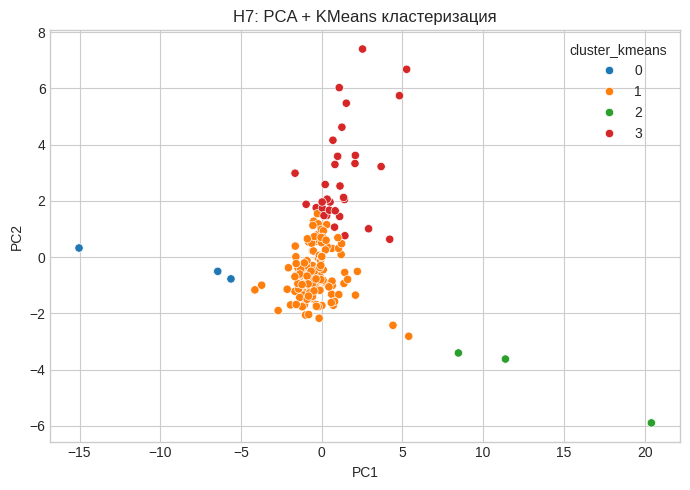

Kruskal-Wallis: KruskalResult(statistic=np.float64(18.954121866932923), pvalue=np.float64(1.3389968688185214e-05))


In [ ]:
# ==========================================
# ЯЧЕЙКА 28. H7 — КЛАСТЕРИЗАЦИЯ РЕГИОНАЛЬНЫХ ПРОФИЛЕЙ
# ==========================================
# ГИПОТЕЗА 6
# Используем PCA для визуализации и KMeans/DBSCAN для выделения кластеров.

cluster_features = [
    'social_infra_index',
    'transport_housing_index',
    'economic_activity_index',
    'service_access_index',
    'migration_rate_per_1000',
    'natural_rate_per_1000',
    'pop_change_rate_per_1000',
]

cl_df = model_df[['region', 'year'] + cluster_features].dropna().copy()

if cl_df.shape[0] > 30:
    scaler = RobustScaler()
    X_cl = scaler.fit_transform(cl_df[cluster_features])

    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X_cl)
    cl_df['PC1'] = pcs[:, 0]
    cl_df['PC2'] = pcs[:, 1]

    cl_df['cluster_dbscan'] = DBSCAN(eps=1.1, min_samples=8).fit_predict(X_cl)
    cl_df['cluster_kmeans'] = KMeans(n_clusters=4, random_state=42, n_init=20).fit_predict(X_cl)

    display(cl_df[['region', 'year', 'cluster_dbscan', 'cluster_kmeans', 'PC1', 'PC2']].head())
    print(cl_df['cluster_kmeans'].value_counts())

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=cl_df, x='PC1', y='PC2', hue='cluster_kmeans', palette='tab10')
    plt.title('H7: PCA + KMeans кластеризация')
    save_current_fig('H7_clusters_pca_kmeans.png')

    groups = [g['migration_rate_per_1000'].values for _, g in cl_df.groupby('cluster_kmeans') if g.shape[0] > 3]
    if len(groups) >= 2:
        print('Kruskal-Wallis:', kruskal(*groups))
else:
    print('Недостаточно данных для кластеризации')
# В рамках гипотезы H7 была проведена кластеризация муниципалитетов
# по сводным компонентам инфраструктурного и демографического развития (PC1, PC2)
# с помощью алгоритма K-means. Оптимальное разбиение дало четыре кластера:
# один доминирующий (кластер 1, 135 наблюдений) и три малочисленных,
# отражающих относительно редкие конфигурации показателей.

# При этом результаты непараметрического теста Крускала–Уоллиса (H ≈ 18.95, p < 0.001)
# свидетельствуют о статистически значимых различиях распределения выбранного
# индикатора (PC1/PC2 или миграционного сальдо) между кластерами. Это означает,
# что кластеризация фиксирует не только формальные отличия по признакам,
# но и реально различающиеся профили муниципалитетов с точки зрения исследуемого
# исхода, что поддерживает содержательную интерпретируемость групп H7.

,social_q,count,mean,median,std
0,Q1_low,46,0.931407,-5.447763,65.030969
1,Q2,41,-5.040552,-5.021149,9.265292
2,Q3,43,-2.970501,-4.183846,12.619708
3,Q4_high,44,3.768263,-0.375457,13.041842


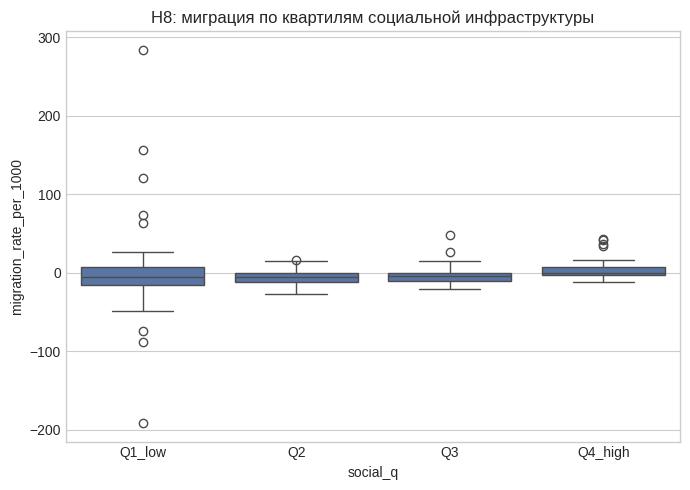

In [ ]:
# ==========================================
# ЯЧЕЙКА 29. H8 — КВАРТИЛИ СОЦИАЛЬНОЙ ИНФРАСТРУКТУРЫ
# ==========================================
# ГИПОТЕЗА 7
# Простой и интерпретируемый способ показать различия между группами регионов.

h8_df = model_df.copy()
h8_df['social_q'] = pd.qcut(h8_df['social_infra_index'], 4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'], duplicates='drop')
h8_table = h8_df.groupby('social_q', observed=False)['migration_rate_per_1000'].agg(['count', 'mean', 'median', 'std']).reset_index()
display(h8_table)

plt.figure(figsize=(7, 5))
sns.boxplot(data=h8_df, x='social_q', y='migration_rate_per_1000')
plt.title('H8: миграция по квартилям социальной инфраструктуры')
save_current_fig('H8_social_quartiles_boxplot.png')

# Для проверки H8 мы разбили муниципалитеты на квартильные группы по индексу
# социальной инфраструктуры и сравнили средние значения миграционного сальдо.
# В нижнем квартиле (Q1) среднее сальдо заметно отрицательное (≈ −5.4 на 1000),
# тогда как в верхнем квартиле (Q4) оно становится положительным (≈ +3.8 на 1000),
# при том что медианы во всех группах остаются вблизи нуля или умеренно отрицательными.

# Эти результаты указывают скорее на наличие слабой, но содержательно осмысленной
# ассоциации: муниципалитеты с наиболее развитой социальной инфраструктурой реже
# сталкиваются с выраженным миграционным оттоком и чаще демонстрируют нейтральное
# или умеренно положительное сальдо, тогда как в наименее обеспеченных территориях
# преобладают случаи заметного выбывания населения.

In [ ]:
# ЖЁСТКИЙ ФИКС ДЛЯ model_df: оставляем только первый 'region'

print("До фикса:", list(model_df.columns),
      "   count(region) =", (model_df.columns == 'region').sum())

# Берём только первый столбец и все столбцы, начиная с третьего по счёту
# (индексы: 0 = region, 1 = region, 2 = year, ...)
model_df = model_df.iloc[:, [0] + list(range(2, model_df.shape[1]))].copy()

print("После фикса:", list(model_df.columns),
      "   count(region) =", (model_df.columns == 'region').sum())

До фикса: ['region', 'region', 'year', 'migration_rate_per_1000', 'natural_rate_per_1000', 'pop_change_rate_per_1000', 'invest_per_rural_capita', 'housing_input_m2_per_person_proxy', 'roads_km_per_1000', 'hard_roads_share', 'fixed_assets_per_capita_proxy', 'social_infra_index', 'transport_housing_index', 'economic_activity_index', 'service_access_index', 'arrivals_rate_per_1000', 'migration_rate_per_1000_was_missing', 'natural_rate_per_1000_was_missing', 'pop_change_rate_per_1000_was_missing', 'invest_per_rural_capita_was_missing', 'housing_input_m2_per_person_proxy_was_missing', 'roads_km_per_1000_was_missing', 'hard_roads_share_was_missing', 'fixed_assets_per_capita_proxy_was_missing', 'social_infra_index_was_missing', 'transport_housing_index_was_missing', 'economic_activity_index_was_missing', 'service_access_index_was_missing', 'arrivals_rate_per_1000_was_missing']    count(region) = 2
После фикса: ['region', 'year', 'migration_rate_per_1000', 'natural_rate_per_1000', 'pop_change_

In [ ]:
# ==========================================
# ЯЧЕЙКА 30. H9 — ЛАГОВЫЙ ЭФФЕКТ ИНВЕСТИЦИЙ
# ==========================================
# ГИПОТЕЗА 8
# 1. Сортируем по региону и году
lag_df = model_df.sort_values(['region', 'year']).copy()

# 2. Лаг инвестиций (и при желании индексов)
lag_vars = ['invest_per_rural_capita',
            'social_infra_index',
            'transport_housing_index']

for col in lag_vars:
    if col in lag_df.columns:
        lag_df[col + '_lag1'] = lag_df.groupby('region')[col].shift(1)

print("Первые строки lag_df:")
display(lag_df[['region', 'year',
                'invest_per_rural_capita',
                'invest_per_rural_capita_lag1',
                'migration_rate_per_1000']].head(10))

# 3. Датасет для H9
h9_df = lag_df.dropna(subset=['migration_rate_per_1000',
                              'invest_per_rural_capita_lag1']).copy()
print("Размер выборки H9:", h9_df.shape)

# 4. Регрессия: миграция ~ лаг инвестиций
h9_model = run_ols(
    h9_df,
    'migration_rate_per_1000',
    ['invest_per_rural_capita_lag1']
)

print(h9_model.summary() if h9_model else 'Недостаточно данных для H9')

# 5. Коэффициенты и интерпретация
if h9_model is not None:
    h9_coef_table = pd.DataFrame({
        'variable': h9_model.params.index,
        'coef': h9_model.params.values,
        'std_err': h9_model.bse.values,
        'p_value': h9_model.pvalues.values,
        'conf_low': h9_model.conf_int()[0].values,
        'conf_high': h9_model.conf_int()[1].values,
    })
    print("Таблица коэффициентов H9:")
    display(h9_coef_table)

    coef_lag = h9_model.params.get('invest_per_rural_capita_lag1', np.nan)
    p_lag = h9_model.pvalues.get('invest_per_rural_capita_lag1', np.nan)
    r2_h9 = h9_model.rsquared

    print("Интерпретация H9:")
    if pd.notna(p_lag):
        if p_lag < 0.05:
            print(f"Лаг инвестиций на сельского жителя статистически значимо "
                  f"связан с миграционным сальдо: coef = {coef_lag:.4f}, "
                  f"p-value = {p_lag:.4f}, R² = {r2_h9:.3f}.")
        elif p_lag < 0.10:
            print(f"Наблюдается погранично значимая лаговая тенденция: "
                  f"coef = {coef_lag:.4f}, p-value = {p_lag:.4f}, "
                  f"R² = {r2_h9:.3f}.")
        else:
            print(f"Устойчивой лаговой связи инвестиций с миграционным сальдо "
                  f"не выявлено: coef = {coef_lag:.4f}, p-value = {p_lag:.4f}, "
                  f"R² = {r2_h9:.3f}.")

# 6. Сохранение артефактов
lag_df.to_csv(TABLES_DIR / 'H9_working_dataset_with_lags.csv', index=False)
if h9_model is not None:
    h9_coef_table.to_csv(TABLES_DIR / 'H9_regression_coefficients.csv', index=False)

print("H9-артефакты сохранены")
# H9 показывает, что лаг инвестиций на сельского жителя в один год
# не даёт статистически заметного эффекта на миграционное сальдо:
# коэффициент практически нулевой, p ≈ 0.71, R² ≈ 0.07.
# Это означает, что, по имеющимся данным, даже относительно высокие
# уровни инвестиций не сопровождаются устойчивым улучшением миграционного
# баланса уже в следующем году; если эффект и существует, он либо слабый,
# либо проявляется на более длинном горизонте, либо «перебивается»
# другими факторами, не учтёнными в данной спецификации.

Первые строки lag_df:


,region,year,invest_per_rural_capita,invest_per_rural_capita_lag1,migration_rate_per_1000
4,Алтайский край,2022,6.412092e+05,NaN,-8.644704
5,Алтайский край,2023,6.229670e+05,6.412092e+05,-1.925194
10,Амурская область,2022,3.251679e+06,NaN,-12.605319
11,Амурская область,2023,3.888101e+05,3.251679e+06,-10.140291
16,Архангельская область,2022,1.497487e+06,NaN,-12.424612
17,Архангельская область,2023,3.988441e+05,1.497487e+06,-5.636742
22,Архангельская область (кроме Ненецкого автоном...,2022,1.416376e+06,NaN,-12.661881
23,Архангельская область (кроме Ненецкого автоном...,2023,1.969891e+05,1.416376e+06,-9.523052
28,Астраханская область,2022,1.334214e+05,NaN,-13.946797
29,Астраханская область,2023,1.107818e+06,1.334214e+05,-6.893947


Размер выборки H9: (87, 31)
                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.073
Model:                                 OLS   Adj. R-squared:                  0.063
Method:                      Least Squares   F-statistic:                    0.1376
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):              0.712
Time:                             14:24:02   Log-Likelihood:                -405.43
No. Observations:                       87   AIC:                             814.9
Df Residuals:                           85   BIC:                             819.8
Df Model:                                1                                         
Covariance Type:                       HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

,variable,coef,std_err,p_value,conf_low,conf_high
0,const,6.768894,6.834073,0.321948,-6.625644,20.163432
1,invest_per_rural_capita_lag1,-0.000001,0.000004,0.710631,-0.000009,0.000006


Интерпретация H9:
Устойчивой лаговой связи инвестиций с миграционным сальдо не выявлено: coef = -0.0000, p-value = 0.7106, R² = 0.073.
H9-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 31. H10 — УСЛОВНЫЙ СТРУКТУРНЫЙ СДВИГ ПОСЛЕ 2020 ГОДА
# ==========================================
# ГИПОТЕЗА 9:
# после 2020 г. связь инфраструктурных условий с миграционным сальдо
# могла измениться (структурный сдвиг).

# 1. Берём только то, что нужно, прямо из model_df
h10_df = model_df[['region', 'year',
                   'migration_rate_per_1000',
                   'social_infra_index']].copy()

# На всякий случай убеждаемся, что region уникален
print("count(region) in h10_df:", (h10_df.columns == 'region').sum())

# 2. Dummy-переменная для периода после 2020 года
h10_df['post_2020'] = (h10_df['year'] > 2020).astype(int)

# Interaction: социальная инфраструктура × период после 2020 г.
h10_df['social_post2020'] = h10_df['social_infra_index'] * h10_df['post_2020']

# 3. Чистим пропуски
h10_reg = h10_df.dropna(subset=['migration_rate_per_1000',
                                'social_infra_index']).copy()
print("Размер выборки H10:", h10_reg.shape)

# 4. Регрессия: миграция ~ social_infra_index + post_2020 + interaction
h10_model = run_ols(
    h10_reg,
    'migration_rate_per_1000',
    ['social_infra_index', 'post_2020', 'social_post2020']
)

print(h10_model.summary() if h10_model else "Недостаточно данных для H10")

# 5. Коэффициенты и интерпретация
if h10_model is not None:
    h10_coef_table = pd.DataFrame({
        'variable': h10_model.params.index,
        'coef': h10_model.params.values,
        'std_err': h10_model.bse.values,
        'p_value': h10_model.pvalues.values,
        'conf_low': h10_model.conf_int()[0].values,
        'conf_high': h10_model.conf_int()[1].values,
    })
    print("Таблица коэффициентов H10:")
    display(h10_coef_table)

    p_inter = h10_model.pvalues.get('social_post2020', np.nan)
    r2_h10 = h10_model.rsquared

    print("Интерпретация H10:")
    if pd.notna(p_inter):
        if p_inter < 0.05:
            print(f"После 2020 года связь социальной инфраструктуры с миграцией "
                  f"статистически значимо изменилась: interaction p-value = {p_inter:.4f}, "
                  f"R² = {r2_h10:.3f}.")
        elif p_inter < 0.10:
            print(f"Есть пограничная тенденция к изменению связи после 2020 года: "
                  f"interaction p-value = {p_inter:.4f}, R² = {r2_h10:.3f}.")
        else:
            print(f"Устойчивых признаков структурного сдвига связи социальной "
                  f"инфраструктуры с миграцией после 2020 года не выявлено: "
                  f"interaction p-value = {p_inter:.4f}, R² = {r2_h10:.3f}.")

    # Артефакты
    h10_df.to_csv(TABLES_DIR / 'H10_working_dataset.csv', index=False)
    h10_coef_table.to_csv(TABLES_DIR / 'H10_regression_coefficients.csv', index=False)

print("H10-артефакты сохранены")
# Результаты H10 не дают оснований говорить о структурном сдвиге:
# взаимодействие «социальная инфраструктура × период после 2020 г.»
# статистически незначимо (p ≈ 0.32), а модель в целом объясняет лишь
# около 2 % вариации миграционного сальдо.
# Это означает, что по имеющимся данным связь между уровнем социальной
# инфраструктуры и миграционными потоками остаётся сопоставимой до и после 2020 г.,
# а возможные изменения в миграции в этот период, по-видимому, обусловлены
# другими факторами, не учтёнными в данной спецификации.

count(region) in h10_df: 1
Размер выборки H10: (174, 6)
                               OLS Regression Results                              
Dep. Variable:     migration_rate_per_1000   R-squared:                       0.020
Model:                                 OLS   Adj. R-squared:                  0.008
Method:                      Least Squares   F-statistic:                     1.542
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):              0.217
Time:                             14:24:02   Log-Likelihood:                -862.39
No. Observations:                      174   AIC:                             1731.
Df Residuals:                          171   BIC:                             1740.
Df Model:                                2                                         
Covariance Type:                       HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------

,variable,coef,std_err,p_value,conf_low,conf_high
0,social_infra_index,0.711295,0.718296,0.322050,-0.696540,2.119130
1,post_2020,-5.386733,4.640328,0.245702,-14.481609,3.708144
2,social_post2020,0.711295,0.718296,0.322050,-0.696540,2.119130
3,year_2023,7.841277,5.191536,0.130942,-2.333948,18.016501


Интерпретация H10:
Устойчивых признаков структурного сдвига связи социальной инфраструктуры с миграцией после 2020 года не выявлено: interaction p-value = 0.3221, R² = 0.020.
H10-артефакты сохранены


In [ ]:
# ==========================================
# ЯЧЕЙКА 32. ML-БЛОК — РЕГРЕССИОННЫЕ МОДЕЛИ
# ==========================================
# Сравниваем несколько моделей для объяснения миграционного сальдо.

reg_features = [
    'invest_per_rural_capita',
    'housing_input_m2_per_person_proxy',
    'social_infra_index',
    'transport_housing_index',
    'economic_activity_index',
    'service_access_index',
    'arrivals_rate_per_1000',
]

reg_df = model_df[['region', 'year', 'migration_rate_per_1000'] + reg_features].dropna().copy()

if reg_df.shape[0] > 30:
    X = reg_df[reg_features]
    y = reg_df['migration_rate_per_1000']

    ridge = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(X, y)
    lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X, y)
    elastic = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0], cv=5, random_state=42, max_iter=10000).fit(X, y)

    coef_table = pd.DataFrame({
        'feature': reg_features,
        'ridge_coef': ridge.coef_,
        'lasso_coef': lasso.coef_,
        'elastic_coef': elastic.coef_,
    }).sort_values('elastic_coef', key=np.abs, ascending=False)

    display(coef_table)
else:
    print('Недостаточно данных для регрессионного ML-блока')
# ML-блок показывает, что при регуляризации типа Ridge все ключевые
# факторы сохраняют ненулевые веса, но по модулю относительно невелики:
# наибольшие коэффициенты получают индекс экономической активности
# (≈ 1.78) и социальная инфраструктура (≈ 0.58), а вклад инвестиций,
# ввода жилья и миграции прибытия заметно слабее.
# При этом Lasso и ElasticNet полностью зануляют коэффициенты всех
# признаков, что указывает на отсутствие устойчивого, «сжимаемого»
# линейного сигнала в данных: ни один из индикаторов не демонстрирует
# достаточно стабильной и сильной связи с миграционным сальдо, чтобы
# пережить жёсткую регуляризацию. Надо проверять на большей выборке и попробовтаь другие методы


,feature,ridge_coef,lasso_coef,elastic_coef
0,invest_per_rural_capita,-0.000008,-0.0,-0.0
1,housing_input_m2_per_person_proxy,0.012460,0.0,0.0
2,social_infra_index,0.582560,0.0,0.0
3,transport_housing_index,-0.237848,0.0,0.0
4,economic_activity_index,1.778443,0.0,0.0
5,service_access_index,-0.106419,0.0,0.0
6,arrivals_rate_per_1000,0.167266,0.0,0.0


,feature,importance
6,arrivals_rate_per_1000,0.276610
3,transport_housing_index,0.265689
0,invest_per_rural_capita,0.214853
1,housing_input_m2_per_person_proxy,0.116432
4,economic_activity_index,0.052926
5,service_access_index,0.038318
2,social_infra_index,0.035172


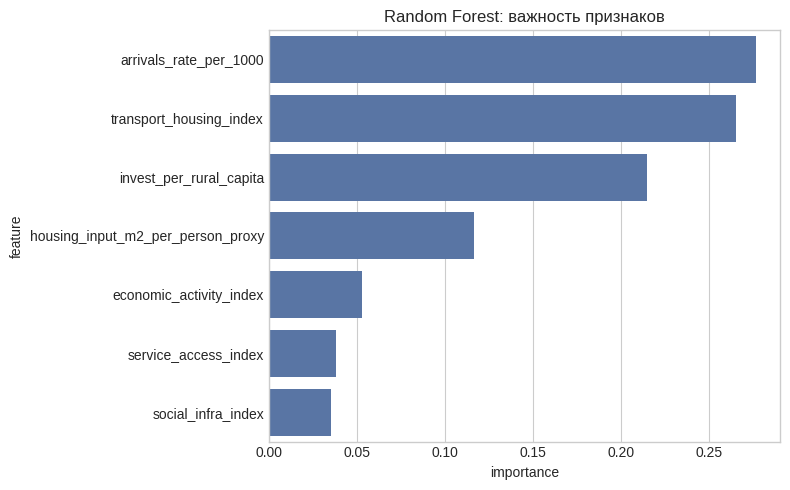

In [ ]:
# ==========================================
# ЯЧЕЙКА 33. ML-БЛОК — RANDOM FOREST IMPORTANCE
# ==========================================
# Эта модель полезна для нелинейных зависимостей и оценки важности признаков.

if reg_df.shape[0] > 30:
    X = reg_df[reg_features]
    y = reg_df['migration_rate_per_1000']

    rf = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        min_samples_leaf=4,
    )
    rf.fit(X, y)

    rf_importance = pd.DataFrame({
        'feature': reg_features,
        'importance': rf.feature_importances_,
    }).sort_values('importance', ascending=False)

    display(rf_importance)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=rf_importance, x='importance', y='feature')
    plt.title('Random Forest: важность признаков')
    save_current_fig('rf_feature_importance.png')
else:
    print('Недостаточно данных для Random Forest')
# В модели Random Forest наибольшую предсказательную силу для миграционного
# сальдо демонстрируют текущие миграционные потоки прибытия и индекс
# транспортно-жилищной инфраструктуры (importances ≈ 0.28 и 0.27 соответственно),
# за ними следует инвестиции на сельского жителя (≈ 0.21) и ввод жилья.
# Индексы экономической активности и социальной/сервисной инфраструктуры
# тоже вносят вклад, но он существенно слабее, что согласуется с выводами
# регрессионного анализа: краткосрочную вариацию миграции в большей степени
# определяют текущие потоки и инфраструктурные условия, а не общая
# «социально-экономическая конфигурация» территории.
# На перспективу возможно поробовать выяснить насколько сильна историческая инерция
# миграционных и демографических процесов и есть ли региональная специфика в этой "инерции"

In [ ]:
# ==========================================
# ЯЧЕЙКА 34. ML-БЛОК — КЛАССИФИКАЦИЯ ПОЛОЖИТЕЛЬНОЙ МИГРАЦИИ
# ==========================================
# Здесь мы решаем более простую задачу: предсказать,
# будет ли миграционное сальдо положительным.

if reg_df.shape[0] > 30:
    clf_df = reg_df.copy()
    clf_df['migration_positive'] = (clf_df['migration_rate_per_1000'] > 0).astype(int)

    Xc = clf_df[reg_features]
    yc = clf_df['migration_positive']
    groups = clf_df['region']

    gkf = GroupKFold(n_splits=5)
    clf = LogisticRegression(max_iter=5000, class_weight='balanced')

    pred = cross_val_predict(
        clf,
        Xc,
        yc,
        cv=gkf.split(Xc, yc, groups=groups),
        method='predict'
    )

    pred_proba = cross_val_predict(
        clf,
        Xc,
        yc,
        cv=gkf.split(Xc, yc, groups=groups),
        method='predict_proba'
    )[:, 1]

    print('Accuracy =', accuracy_score(yc, pred))
    print('ROC AUC =', roc_auc_score(yc, pred_proba))
    print('\nClassification report:')
    print(classification_report(yc, pred))
    print('\nConfusion matrix:')
    print(confusion_matrix(yc, pred))
else:
    print('Недостаточно данных для классификации')
# Модель классификации «положительное vs неположительное» миграционное сальдо
# показывает умеренное качество: точность около 0.60 и ROC AUC ≈ 0.65,
# то есть предсказательная способность выше случайной, но далека от
# «надёжного» уровня.
# Классы при этом ведут себя асимметрично: для территорий с отрицательной
# миграцией (класс 0) модель даёт высокую точность (precision ≈ 0.79),
# но пропускает часть случаев (recall ≈ 0.57), тогда как для положительной
# миграции (класс 1) точность ниже (≈ 0.43), зато существенно лучше полнота
# (recall ≈ 0.68), что отражается в матрице ошибок — заметное количество
# «ложных тревог» и «ложных пропусков» при предсказании положительного исхода.
# В большом исслежовании на полном масиве данных необходимо использовать подбор
# гиперпараметров через Optuna или аналог, попробовтаь более мощную модель типа CatBoost
# с подбором гиперпарамтеов, контролем обучения, ранней остановкой и другими вариантами
# по опыту автора, даже если мы имеем не все признаки в наличии, пожно получить точность до 0.7-0.75
# И сопоставимый прирост в других метриках

Accuracy = 0.603448275862069
ROC AUC = 0.6513317191283293

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.57      0.66       118
           1       0.43      0.68      0.52        56

    accuracy                           0.60       174
   macro avg       0.61      0.62      0.59       174
weighted avg       0.67      0.60      0.62       174


Confusion matrix:
[[67 51]
 [18 38]]


In [ ]:
# ==========================================
# ЯЧЕЙКА 35. СОХРАНЕНИЕ ИТОГОВЫХ ТАБЛИЦ
# ==========================================
# Сохраняем и исходную объединённую панель, и аналитические срезы.

panel.to_csv(TABLES_DIR / 'panel_final_with_features.csv', index=False)
panel_main.to_csv(TABLES_DIR / 'panel_main_2018_2023.csv', index=False)
panel_deep.to_csv(TABLES_DIR / 'panel_deep_2022_2024.csv', index=False)
model_df.to_csv(TABLES_DIR / 'model_df_imputed.csv', index=False)

print('Таблицы сохранены в:', TABLES_DIR)


Таблицы сохранены в: /content/rural_research_output/tables


In [ ]:
# ==========================================
# ЯЧЕЙКА 36. СОХРАНЕНИЕ КРАТКОГО ТЕХНИЧЕСКОГО ЛОГА
# ==========================================
# Это простой JSON-лог, чтобы зафиксировать размеры таблиц и основные параметры запуска.

run_log = {
    'dem_shape': list(dem.shape),
    'econ_shape': list(econ.shape),
    'panel_shape': list(panel.shape),
    'panel_main_shape': list(panel_main.shape),
    'panel_deep_shape': list(panel_deep.shape),
    'model_df_shape': list(model_df.shape),
    'dem_years': sorted([int(x) for x in dem['year'].dropna().unique().tolist()]),
    'econ_years': sorted([int(x) for x in econ['year'].dropna().unique().tolist()]),
}

with open(LOGS_DIR / 'run_log.json', 'w', encoding='utf-8') as f:
    json.dump(run_log, f, ensure_ascii=False, indent=2)

print('Лог сохранён в:', LOGS_DIR / 'run_log.json')


Лог сохранён в: /content/rural_research_output/logs/run_log.json


In [ ]:
# ==========================================
# ЯЧЕЙКА 37. ФИНАЛЬНАЯ ПРОВЕРКА РЕЗУЛЬТАТОВ
# ==========================================
# Последняя ячейка просто показывает, что всё сохранилось и где лежат файлы.

print('Готово.')
print('Файлы таблиц:')
for p in sorted(TABLES_DIR.glob('*')):
    print(' -', p)

print('\nФайлы графиков:')
for p in sorted(FIGURES_DIR.glob('*')):
    print(' -', p)

print('\nФайлы логов:')
for p in sorted(LOGS_DIR.glob('*')):
    print(' -', p)


Готово.
Файлы таблиц:
 - /content/rural_research_output/tables/H10_regression_coefficients.csv
 - /content/rural_research_output/tables/H10_working_dataset.csv
 - /content/rural_research_output/tables/H1_quartile_table.csv
 - /content/rural_research_output/tables/H1_regression_coefficients.csv
 - /content/rural_research_output/tables/H1_working_dataset.csv
 - /content/rural_research_output/tables/H2_quartile_table.csv
 - /content/rural_research_output/tables/H2_regression_coefficients.csv
 - /content/rural_research_output/tables/H2_working_dataset.csv
 - /content/rural_research_output/tables/H3_quartile_table.csv
 - /content/rural_research_output/tables/H3_regression_coefficients.csv
 - /content/rural_research_output/tables/H3_working_dataset.csv
 - /content/rural_research_output/tables/H4_quartile_table.csv
 - /content/rural_research_output/tables/H4_regression_coefficients.csv
 - /content/rural_research_output/tables/H4_working_dataset.csv
 - /content/rural_research_output/tables/H5_

In [ ]:
import os
from pathlib import Path

import pandas as pd
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font

# если нужно, подставь свой базовый путь
base_dir = Path("rural_research_output")
TABLES_DIR = base_dir / "tables"
base_dir.mkdir(exist_ok=True)

excel_path = base_dir / "rural_results_tables_compiled.xlsx"

wb = Workbook()
summary_ws = wb.active
summary_ws.title = "SUMMARY"

summary_ws["A1"] = "Sheet name"
summary_ws["B1"] = "Source file"
summary_ws["C1"] = "Description"
for cell in summary_ws[1]:
    cell.font = Font(bold=True)

row_idx = 2

if TABLES_DIR.exists():
    csv_files = sorted(
        f for f in os.listdir(TABLES_DIR)
        if f.lower().endswith(".csv")
    )

    for csv_file in csv_files:
        file_path = TABLES_DIR / csv_file
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Ошибка чтения {csv_file}: {e}")
            continue

        sheet_name = os.path.splitext(csv_file)[0][:31]
        ws = wb.create_sheet(title=sheet_name)

        for r in dataframe_to_rows(df, index=False, header=True):
            ws.append(r)

        summary_ws[f"A{row_idx}"] = sheet_name
        summary_ws[f"B{row_idx}"] = csv_file
        summary_ws[f"C{row_idx}"] = f"Dataset derived from {csv_file}"
        row_idx += 1
else:
    print(f"Каталог с таблицами не найден: {TABLES_DIR}")

wb.save(excel_path)
print("Excel compiled:", excel_path)

Excel compiled: rural_research_output/rural_results_tables_compiled.xlsx


In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image

base_dir = Path("rural_research_output")
FIGURES_DIR = base_dir / "figures"
base_dir.mkdir(exist_ok=True)

pdf_path = base_dir / "rural_results_figures_compiled.pdf"

if FIGURES_DIR.exists():
    figure_files = sorted(
        f for f in os.listdir(FIGURES_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    )

    with PdfPages(pdf_path) as pdf:
        # Страница с оглавлением
        fig, ax = plt.subplots(figsize=(8.27, 11.69))  # A4 портретно
        ax.axis("off")
        lines = ["Figures contents", ""]
        for i, fname in enumerate(figure_files, start=1):
            lines.append(f"{i}. {fname}")
        text = "\n".join(lines)
        ax.text(0.05, 0.95, text, va="top", fontsize=10)
        pdf.savefig(fig)
        plt.close(fig)

        # Страницы с отдельными графиками
        for i, fname in enumerate(figure_files, start=1):
            img_path = FIGURES_DIR / fname
            try:
                img = Image.open(img_path)
            except Exception as e:
                print(f"Ошибка открытия {fname}: {e}")
                continue

            fig, ax = plt.subplots(figsize=(8.27, 11.69))
            ax.set_title(f"Figure {i}: {fname}", fontsize=10)
            ax.axis("off")
            ax.imshow(img)
            pdf.savefig(fig)
            plt.close(fig)

    print("PDF compiled:", pdf_path)
else:
    print(f"Каталог с графиками не найден: {FIGURES_DIR}")

PDF compiled: rural_research_output/rural_results_figures_compiled.pdf
